In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spacy.lang.en.tokenizer_exceptions import data_apos

sns.set_theme(style="whitegrid")

In [2]:
# UWAGA tu bierzemy zawsze już czyste dane
data = data = pd.read_csv(('../data/merged/clean_data.csv'))

In [3]:
labels = ['1950-1969', '1970-1989', '1990-2009', '2010-obecnie']
data['epoka'] = pd.Categorical(data['epoka'], categories=labels, ordered=True)

In [4]:
print(data.shape)
data.sample(5)

(19120, 68)


,tmdbId,title,budget,revenue,release_date,runtime,original_language,popularity,vote_average,vote_count,...,Semitckie,Indoeuropejskie,Germańskie,Inne/nieznane,Sztuczne,Słowiańskie,Izolat/nieklasyfikowane,Azjatyckie,Uralskie,Romańskie
6273,27274.0,Frankenhooker,2500000.0,205068,1990-06-01,85,en,2.0659,6.294,369,...,0,0,1,0,0,0,0,0,0,0
8616,56934.0,Bride of the Wind,NaN,419414,2001-06-08,99,en,1.0130,3.750,8,...,0,0,1,0,0,0,0,0,0,0
9945,85446.0,Step Up Revolution,33000000.0,140470746,2012-07-26,99,en,3.3959,6.913,2109,...,0,0,1,0,0,0,0,0,0,0
5256,19025.0,Bhool Bhulaiyaa,3800000.0,9900000,2007-10-12,158,hi,1.7583,6.702,196,...,0,0,0,0,0,0,0,1,0,0
11406,184315.0,Hercules,100000000.0,244819862,2014-07-23,98,en,9.4298,5.796,4297,...,0,0,1,0,0,0,0,0,0,0


# Statystyki kolumn

In [5]:
# STATYSTYKI OPISOWE  trochę nie mają sensu bo dane aż tak skośne, dużo wartości odstających
num_data = data.loc[:, ['budget_adjusted', 'revenue_adjusted','runtime', 'popularity',
                        'vote_average', 'vote_count']]


stats = num_data.describe().T[['mean', '50%', 'std', 'min', 'max']]
stats.rename(columns={'50%': 'median'}, inplace=True)

stats['skewness'] = num_data.skew()
stats['kurtosis'] = num_data.kurtosis()
stats = round(stats,2)
stats

,mean,median,std,min,max,skewness,kurtosis
budget_adjusted,39322243.45,19685230.68,5.454743e+07,10029.38,6.169198e+08,2.80,10.66
revenue_adjusted,73811440.05,9154518.84,2.026692e+08,10052.91,4.541628e+09,7.17,83.66
runtime,107.28,103.00,2.226000e+01,51.00,5.660000e+02,2.61,23.55
popularity,2.77,1.75,4.920000e+00,0.01,3.193300e+02,22.86,1088.81
vote_average,6.17,6.32,1.290000e+00,0.00,1.000000e+01,-1.99,7.39
vote_count,1064.20,188.00,2.623360e+03,0.00,3.915600e+04,5.38,39.38


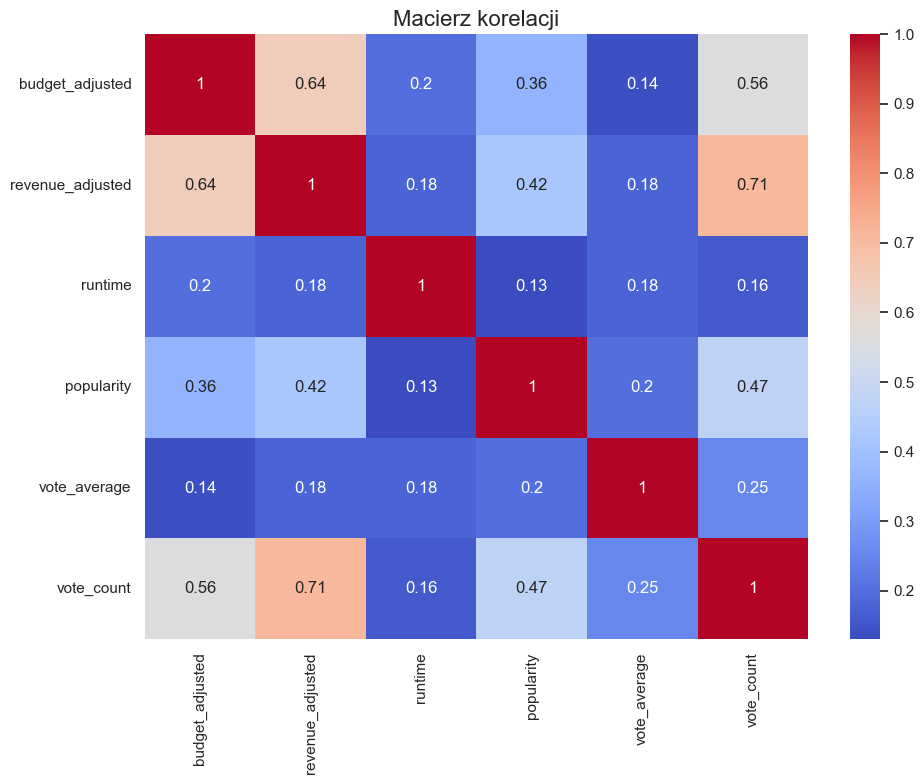

In [6]:
cor_matrix = round(num_data.corr(),2)
plt.figure(figsize=(10, 8))


sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.title('Macierz korelacji', fontsize=16)
plt.tight_layout()
plt.show() 

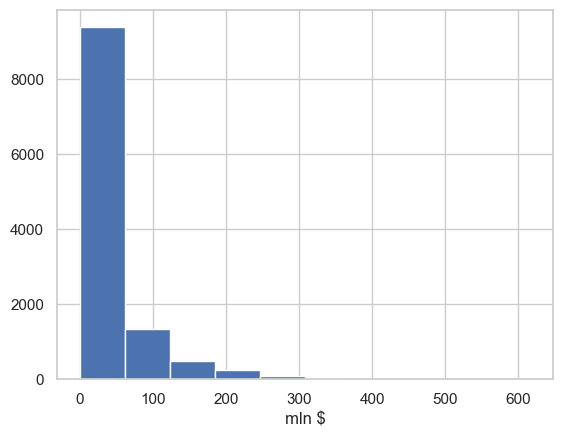

In [7]:
plt.hist(data['budget_adjusted'] / 1e6)
plt.xlabel("mln $")
plt.show()

In [8]:
len(data[data['budget_adjusted'] > 300e6])

60

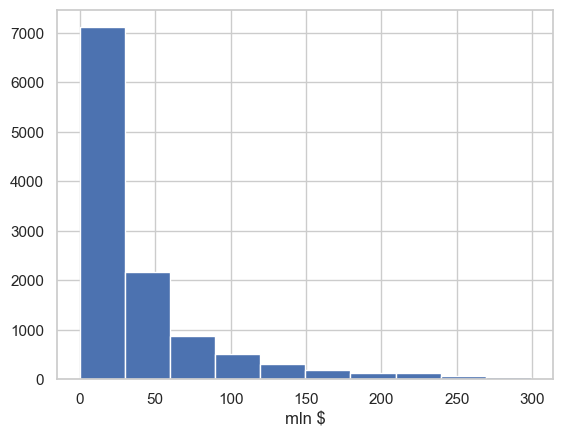

In [9]:
plt.hist(data[data['budget_adjusted'] < 300e6]['budget_adjusted'] / 1e6)
plt.xlabel("mln $")
plt.show()

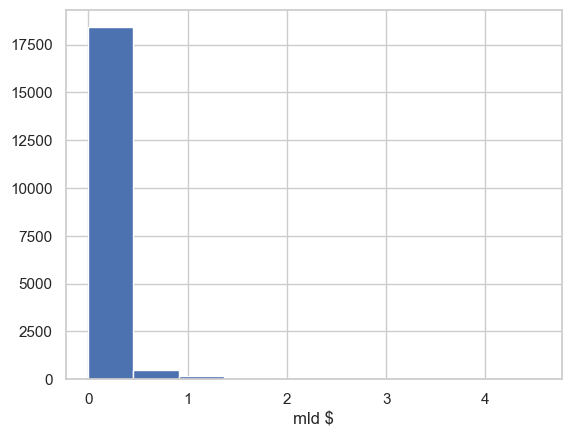

In [10]:
plt.hist(data['revenue_adjusted'] / 1e9)
plt.xlabel("mld $")
plt.show()

In [11]:
len(data[data['revenue_adjusted'] > 2e9])

23

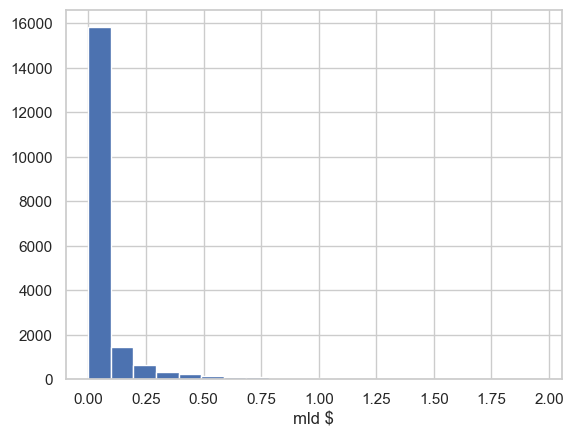

In [12]:
plt.hist(data[data['revenue_adjusted'] < 2e9]['revenue_adjusted'] / 1e9, bins = 20)
plt.xlabel("mld $")
plt.show()

In [13]:
rev = data['revenue_adjusted']
total_movies = len(rev)
less_than_100k = len(rev[rev < 100_000])
less_than_1m = len(rev[rev < 1_000_000])
less_than_10m = len(rev[rev < 10_000_000])
less_than_100m = len(rev[rev < 100_000_000])
less_than_1mld = len(rev[rev < 1000_000_000])

tabela_ryzyka = pd.DataFrame({
    'Revenue_adjusted': ['< 100 tys', '< 1 mln', '< 10 mln', '< 100 mln', '< 1 mld'],
    'Liczba filmów': [less_than_100k, less_than_1m, less_than_10m, less_than_100m, less_than_1mld],
    'Odsetek (%)': [
        round((less_than_100k / total_movies) * 100, 2),
        round((less_than_1m / total_movies) * 100, 2),
        round((less_than_10m / total_movies) * 100, 2),
        round((less_than_100m / total_movies) * 100, 2),
        round((less_than_1mld / total_movies) * 100, 2),
    ]
})
tabela_ryzyka

,Revenue_adjusted,Liczba filmów,Odsetek (%)
0,< 100 tys,1552,8.12
1,< 1 mln,4648,24.31
2,< 10 mln,9768,51.09
3,< 100 mln,15876,83.03
4,< 1 mld,18929,99.00


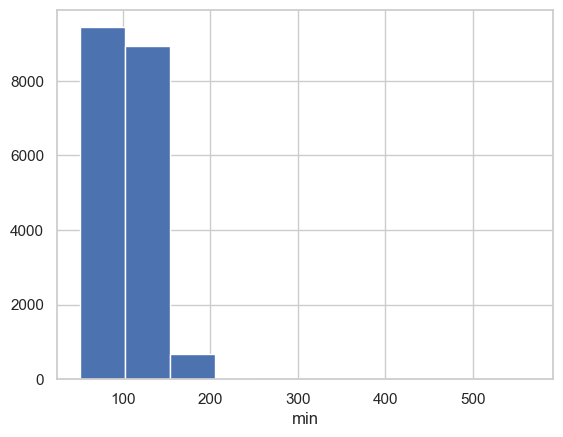

In [14]:
plt.hist(data['runtime'])
plt.xlabel("min")
plt.show()

In [15]:
len(data[data['runtime'] > 300])

10

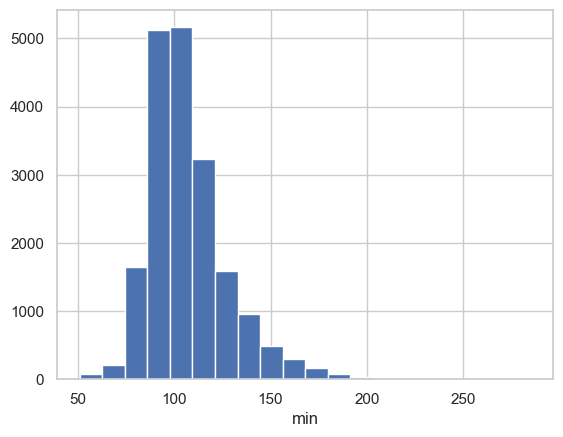

In [16]:
plt.hist(data[data['runtime'] < 300]['runtime'], bins = 20)
plt.xlabel("min")
plt.show()

In [17]:
len(data[data['popularity'] > 30])

58

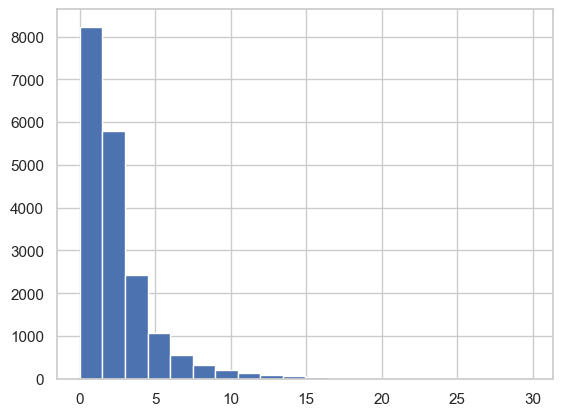

In [18]:
plt.hist(data[data['popularity'] < 30]['popularity'], bins = 20)
plt.show()

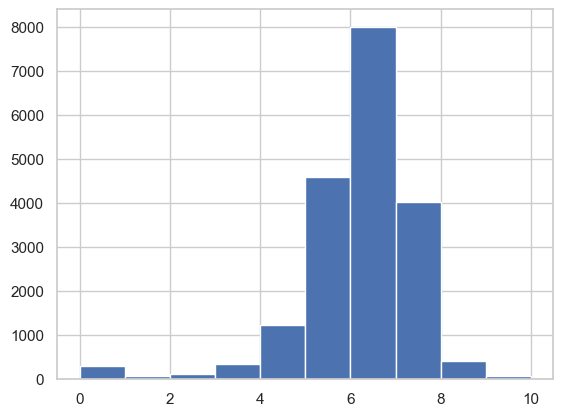

In [19]:
plt.hist(data['vote_average'], bins = 10)
plt.show()

In [20]:
len(data[data['vote_count'] > 20000])

70

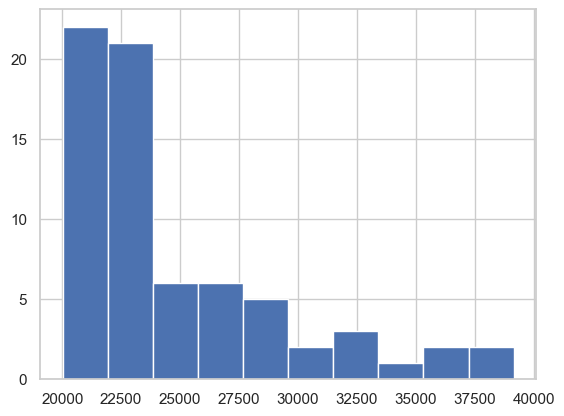

In [21]:
plt.hist(data[data['vote_count'] > 20000]['vote_count'])
plt.show()

# Wizualizacje

In [22]:
data['year'].value_counts().sort_index()

year
1950     22
1951     25
1952     23
1953     31
1954     37
       ... 
2021    421
2022    533
2023    567
2024    635
2025    528
Name: count, Length: 76, dtype: int64

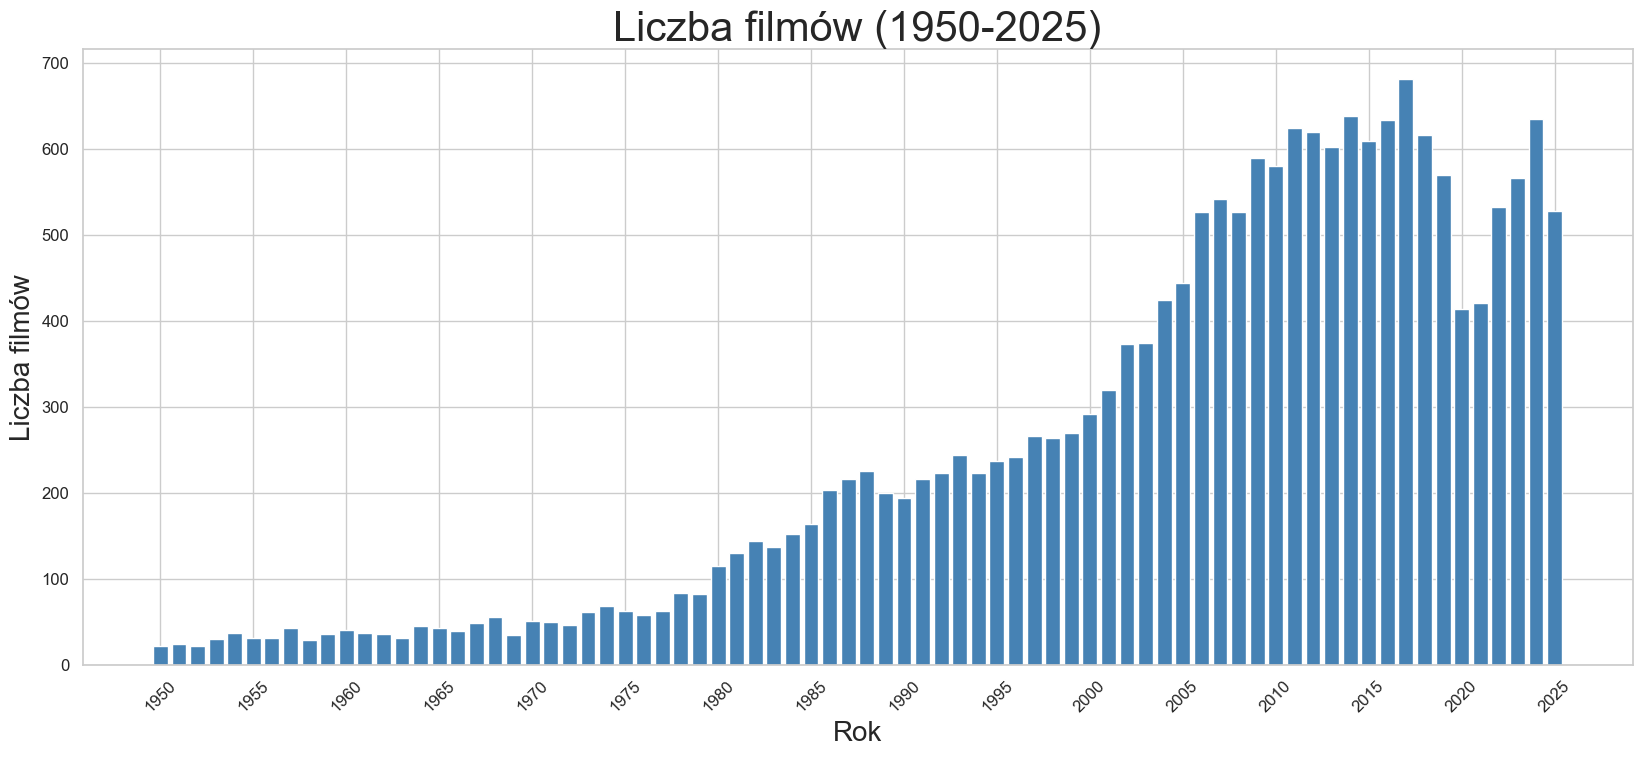

In [23]:
movies_per_year = data['year'].value_counts().sort_index()

plt.figure(figsize=(20, 8))
plt.bar(x = movies_per_year.index,
        height = movies_per_year.values,
        color='steelblue')

plt.title('Liczba filmów (1950-2025)', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Liczba filmów', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

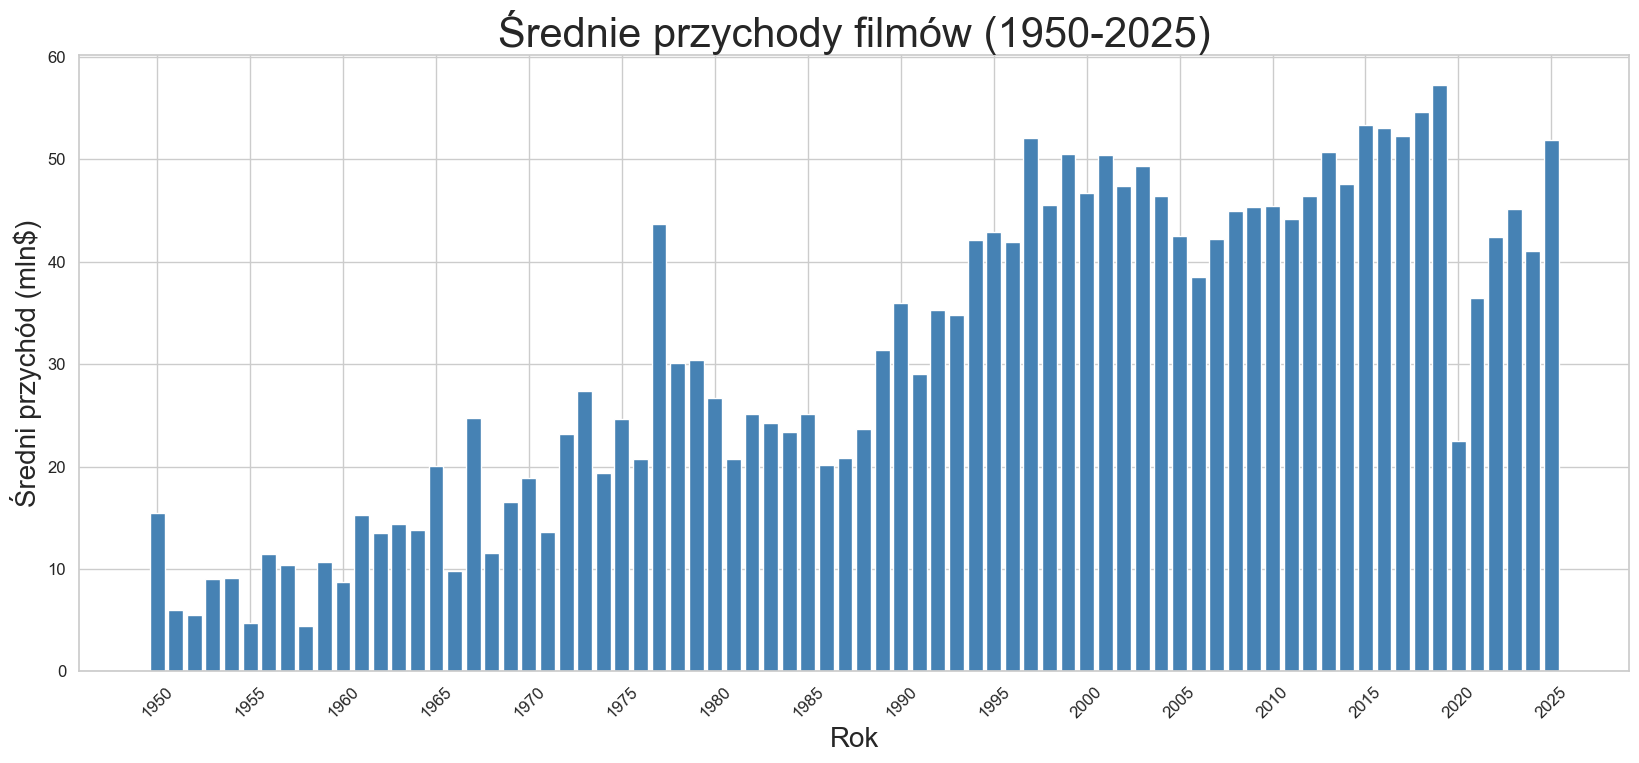

In [24]:
mean_revenue_year = data.groupby('year')['revenue'].mean() / 1e6

plt.figure(figsize=(20, 8))
plt.bar(x = mean_revenue_year.index,
        height = mean_revenue_year.values,
        color='steelblue')

plt.title('Średnie przychody filmów (1950-2025)', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Średni przychód (mln$)', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

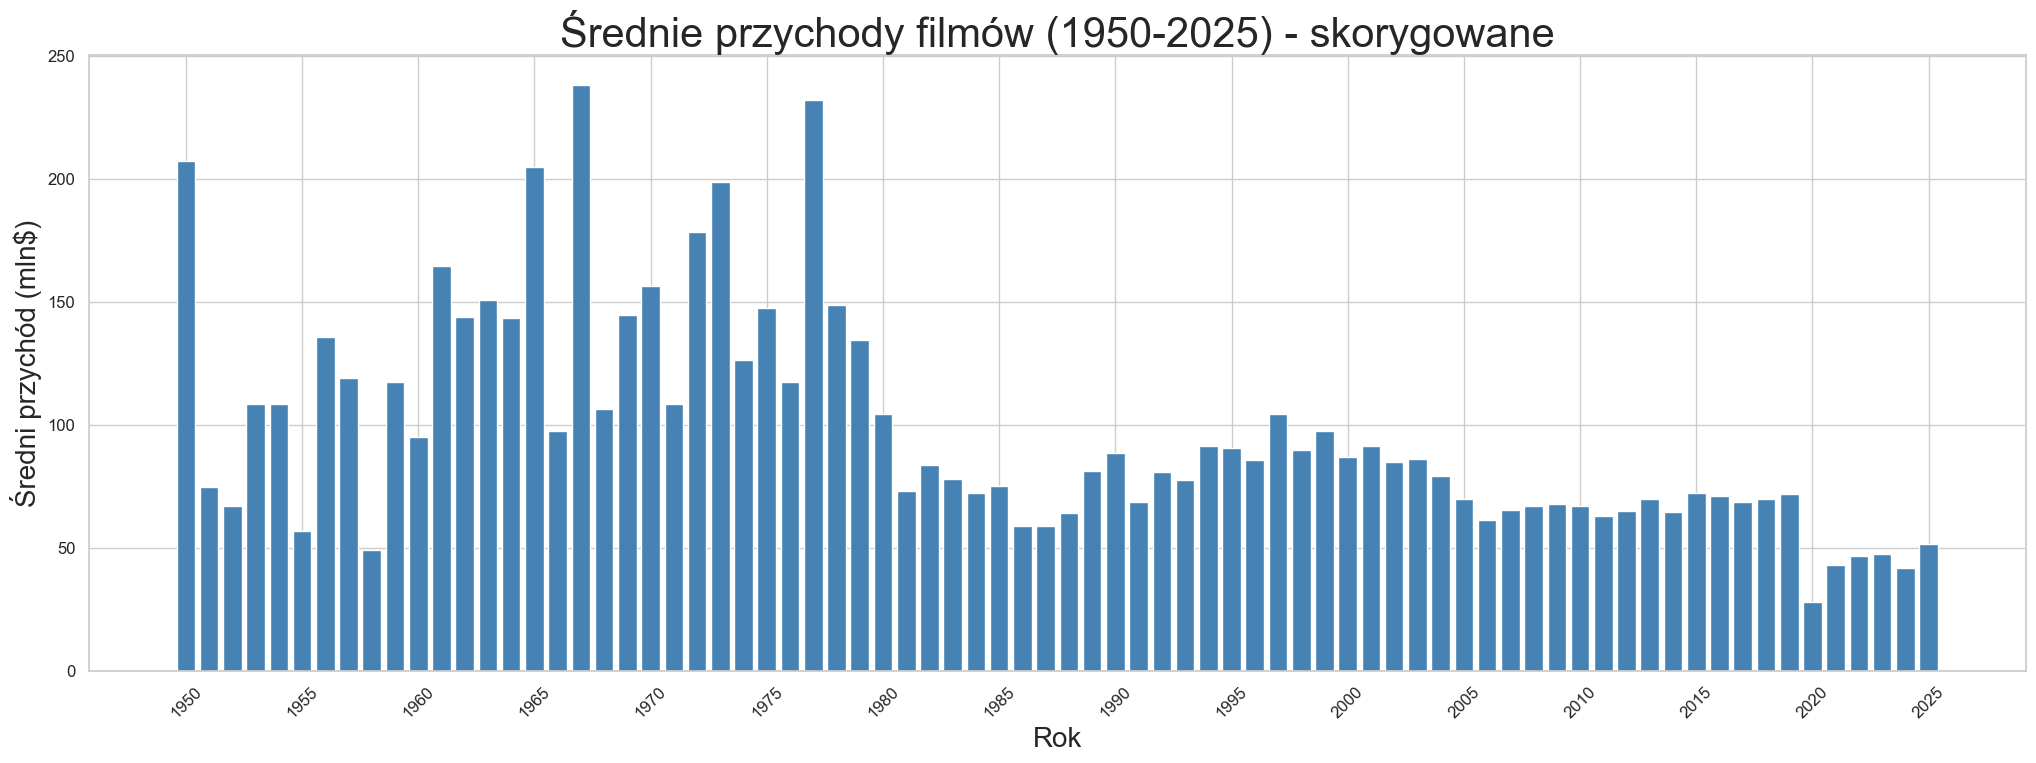

In [25]:
mean_revenue_year = data.groupby('year')['revenue_adjusted'].mean() / 1e6

plt.figure(figsize=(25, 8))
plt.bar(x = mean_revenue_year.index,
        height = mean_revenue_year.values,
        color='steelblue')

plt.title('Średnie przychody filmów (1950-2025) - skorygowane', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Średni przychód (mln$)', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

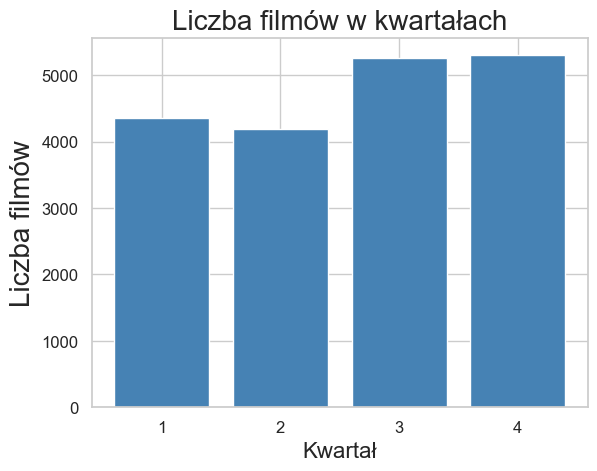

In [26]:
movies_per_quarter = data['quarter'].value_counts().sort_index()

plt.bar(x = movies_per_quarter.index,
        height = movies_per_quarter.values,
        color='steelblue')

plt.title('Liczba filmów w kwartałach', fontsize=20)
plt.xlabel('Kwartał', fontsize = 16)
plt.ylabel('Liczba filmów', fontsize = 20)

plt.xticks(movies_per_quarter.index, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

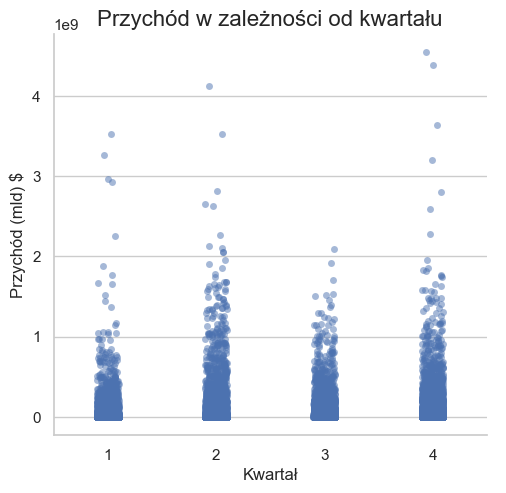

In [27]:
sns.catplot(data=data,  x ="quarter", y ="revenue_adjusted", jitter = True, alpha = 0.5)
plt.title("Przychód w zależności od kwartału", size = 16)
plt.ylabel("Przychód (mld) $")
plt.xlabel("Kwartał")
plt.show()

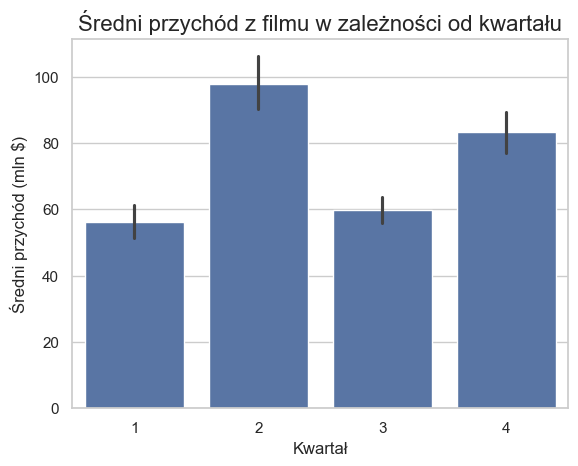

In [28]:
sns.barplot(
    x = data['quarter'], 
    y = (data['revenue_adjusted'] / 1e6), 
    legend=False,  
    errorbar='ci'
)


plt.title('Średni przychód z filmu w zależności od kwartału', fontsize=16)
plt.xlabel('Kwartał', fontsize=12)
plt.ylabel('Średni przychód (mln $)', fontsize=12)

plt.show()

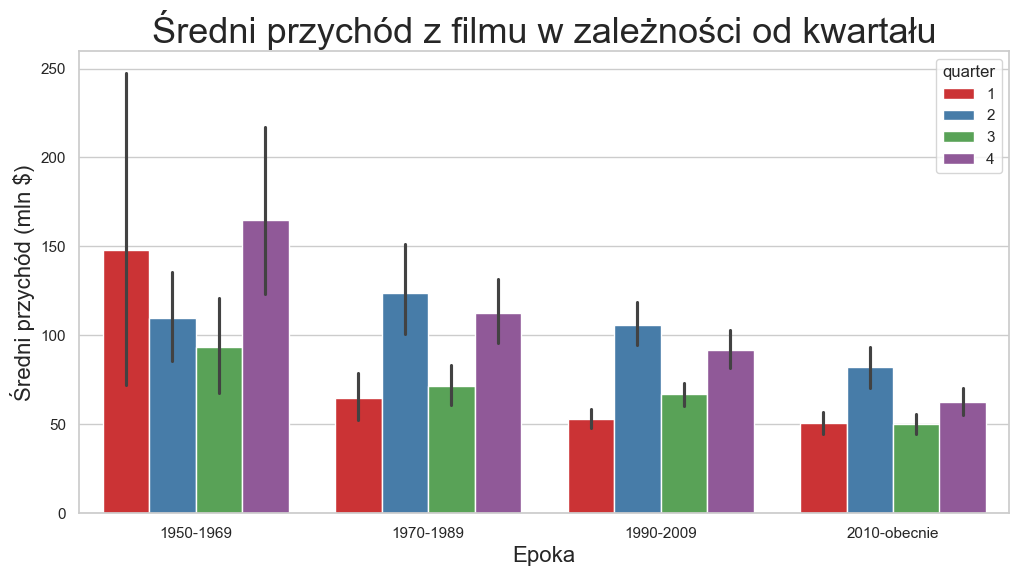

In [29]:
plt.figure(figsize = (12, 6))
sns.barplot(
    x = data['epoka'], 
    y = (data['revenue_adjusted'] / 1e6), 
    hue = data['quarter'],
    legend=True,  
    errorbar='ci',
    palette = 'Set1'
)


plt.title('Średni przychód z filmu w zależności od kwartału', fontsize=26)
plt.xlabel('Epoka', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)

plt.show()

In [30]:
pl_data = data[['revenue_adjusted', 'epoka', 'quarter']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6

tabela = pd.pivot_table(
    pl_data, 
    values='revenue_mln',      
    index='quarter',     
    columns='epoka',         
    aggfunc='mean',         
    margins=True,         
    margins_name='Globalnie' 
)

tabela = round(tabela, 3)
tabela

C:\Users\klang\AppData\Local\Temp\ipykernel_19588\1808230216.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela = pd.pivot_table(


epoka,1950-1969,1970-1989,1990-2009,2010-obecnie,Globalnie
quarter,,,,,
1,148.121,64.651,52.829,50.547,56.113
2,109.688,123.582,105.609,82.050,97.773
3,93.250,71.496,66.823,50.099,59.863
4,164.961,112.711,91.772,62.690,83.265
Globalnie,130.165,95.199,79.030,60.227,73.811


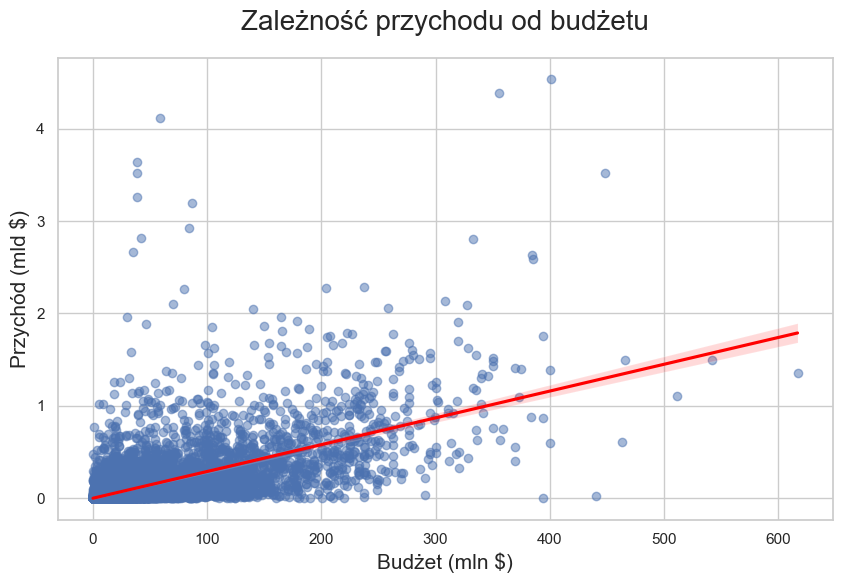

In [31]:
plt.figure(figsize = (10,6))
sns.regplot(x = data['budget_adjusted'] / 1e6, 
            y = data['revenue_adjusted'] / 1e9, 
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'red'})

plt.title('Zależność przychodu od budżetu', fontsize=20, pad=20)
plt.xlabel('Budżet (mln $)', fontsize=15)
plt.ylabel('Przychód (mld $)', fontsize=15)


plt.show()

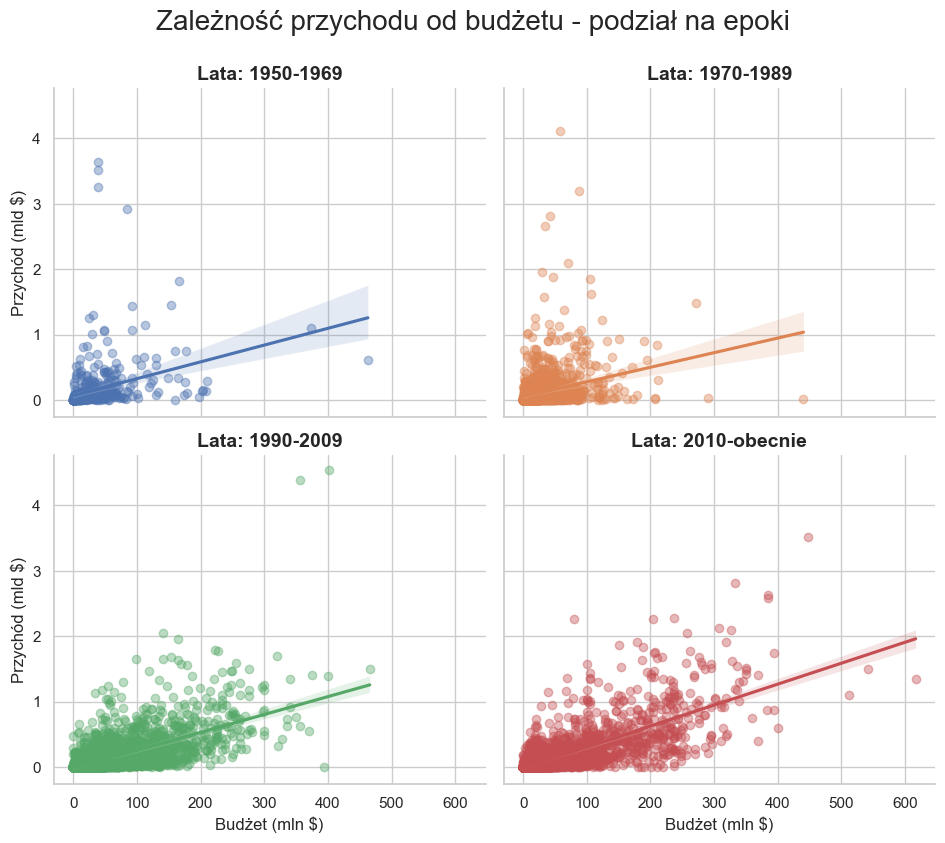

In [32]:
pl_data = data[['year', 'budget_adjusted', 'revenue_adjusted', 'epoka']].copy()

pl_data['budget_mln'] = pl_data['budget_adjusted'] / 1e6
pl_data['revenue_mld'] = pl_data['revenue_adjusted'] / 1e9
pl_data = pl_data.dropna(subset=['budget_mln', 'revenue_mld', 'epoka'])

g = sns.lmplot(
    data=pl_data,
    x='budget_mln',
    y='revenue_mld',
    col='epoka',
    hue = 'epoka' ,      
    col_wrap=2,     
    height=4,      
    aspect=1.2,     
    scatter_kws={'alpha': 0.4},   
)


g.set_axis_labels('Budżet (mln $)', 'Przychód (mld $)')
g.set_titles(col_template='Lata: {col_name}', size=14, weight='bold')

g.figure.suptitle('Zależność przychodu od budżetu - podział na epoki', fontsize=20, y=1.05)

plt.show()

In [33]:
data[['title', 'year', 'revenue_adjusted']].sort_values('revenue_adjusted', ascending=False).head(20)

,title,year,revenue_adjusted
360,Titanic,1997,4.541628e+09
5410,Avatar,2009,4.387433e+09
2,Star Wars,1977,4.119372e+09
2165,The Jungle Book,1967,3.643547e+09
12718,Avengers: Endgame,2019,3.525269e+09
3342,Cinderella,1950,3.521335e+09
3828,One Hundred and One Dalmatians,1961,3.262499e+09
2338,The Exorcist,1973,3.199897e+09
8884,The Dollars Are Coming!,1957,2.960367e+09
4577,The Sound of Music,1965,2.925228e+09


In [34]:
data[['title', 'year', 'budget_adjusted']].sort_values('budget_adjusted', ascending=False).head(20)

,title,year,budget_adjusted
11387,Star Wars: The Rise of Skywalker,2019,6.169198e+08
895,Pirates of the Caribbean: On Stranger Tides,2011,5.424422e+08
15221,Jurassic World Dominion,2022,5.115358e+08
178,Pirates of the Caribbean: At World's End,2007,4.658145e+08
1811,Cleopatra,1963,4.629246e+08
12718,Avengers: Endgame,2019,4.483026e+08
3464,Manhunter,1986,4.406154e+08
360,Titanic,1997,4.011751e+08
329,Spider-Man 3,2007,4.006004e+08
15840,Mission: Impossible - The Final Reckoning,2025,4.000000e+08


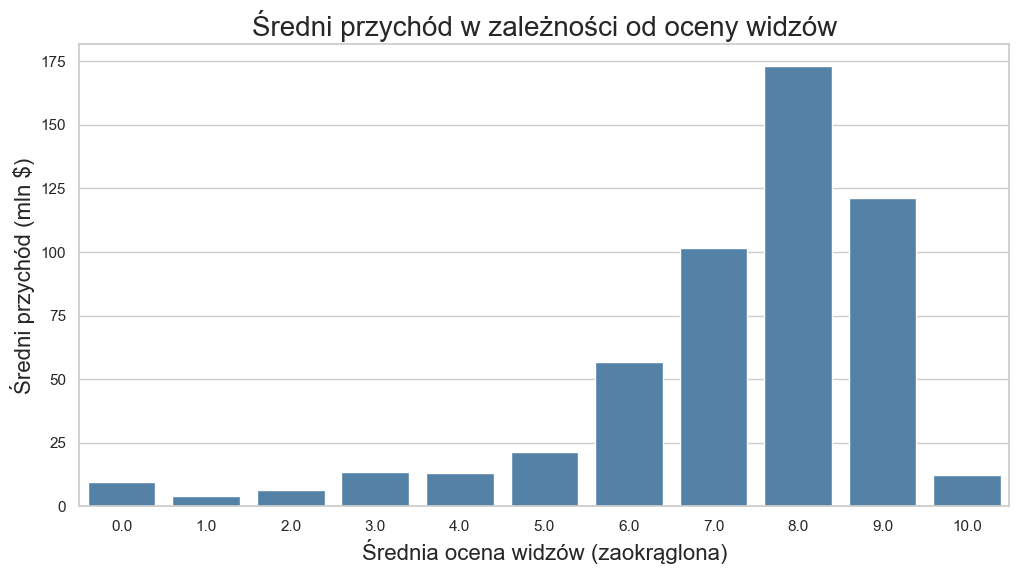

In [35]:
pl_data = data[['revenue_adjusted', 'vote_average', 'epoka']].copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6
pl_data['vote_rounded'] = pl_data['vote_average'].round()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=pl_data,
    x='vote_rounded',
    y='revenue_mln',
    color='steelblue',
    errorbar=None
)

plt.title('Średni przychód w zależności od oceny widzów', fontsize=20)
plt.xlabel('Średnia ocena widzów (zaokrąglona)', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)

plt.show()

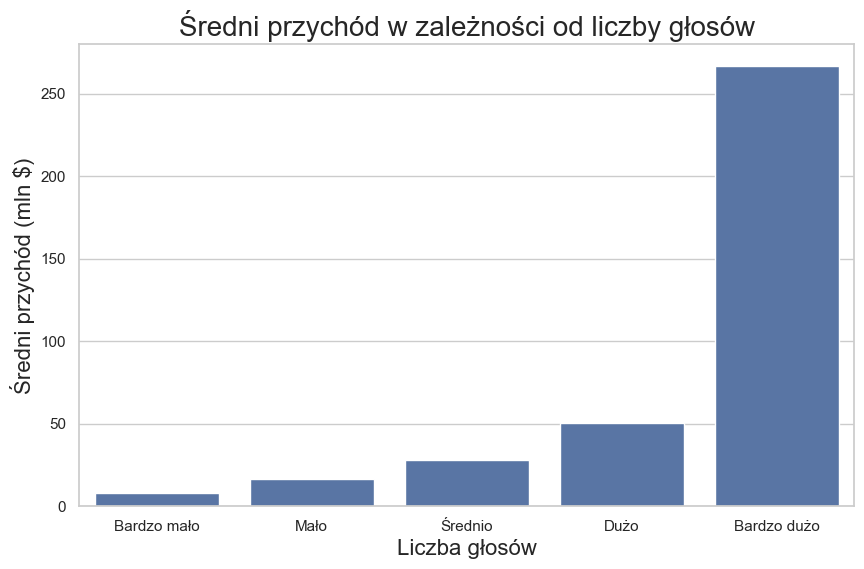

In [36]:
pl_data = data[['revenue_adjusted', 'vote_count']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6

labels = ['Bardzo mało', 'Mało', 'Średnio', 'Dużo', 'Bardzo dużo']
pl_data['vote_category'] = pd.qcut(pl_data['vote_count'], q=5, labels=labels)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=pl_data,
    x='vote_category',
    y='revenue_mln',
    errorbar=None    
)


plt.title('Średni przychód w zależności od liczby głosów', fontsize=20)
plt.xlabel('Liczba głosów', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)


plt.show()

Próg wejścia do grupy 'Bardzo dużo': 2730 głosów



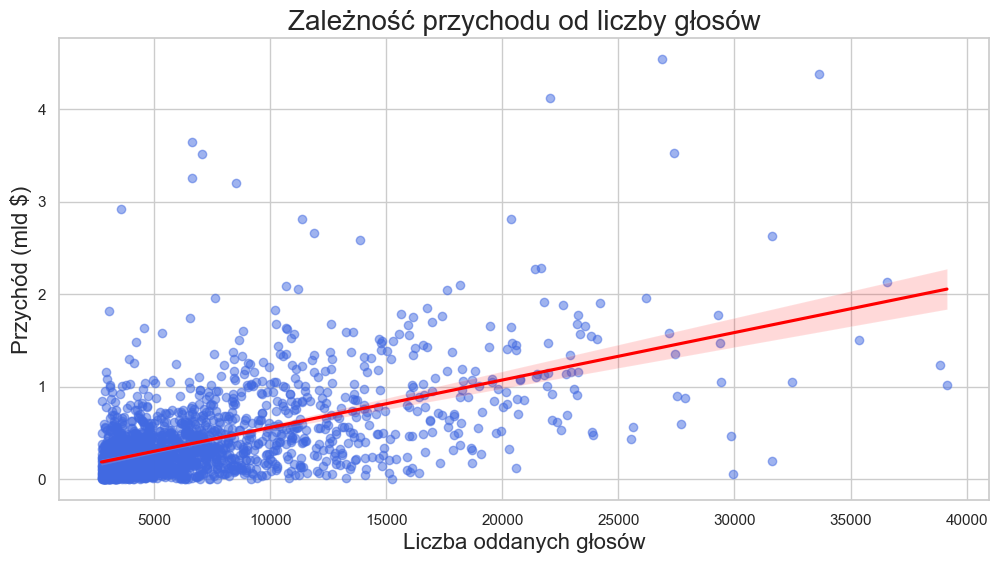

In [37]:
pl_data = data[['revenue_adjusted', 'vote_count']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e9

prog_odciecia = pl_data['vote_count'].quantile(0.9)
print(f"Próg wejścia do grupy 'Bardzo dużo': {round(prog_odciecia)} głosów\n")

pl_data = pl_data[pl_data['vote_count'] >= prog_odciecia]

plt.figure(figsize=(12, 6))

sns.regplot(
    data=pl_data,
    x='vote_count',
    y='revenue_mln', 
    color='royalblue',
    scatter_kws={'alpha': 0.5}, 
    line_kws={'color': 'red'}
)

plt.title('Zależność przychodu od liczby głosów', fontsize=20)
plt.xlabel('Liczba oddanych głosów', fontsize=16)
plt.ylabel('Przychód (mld $)', fontsize=16)

plt.show()

In [38]:
data['main_genre'].value_counts()

main_genre
comedy         4728
action         2492
romance        1547
drama          1487
horror         1384
thriller       1145
crime           939
animation       898
adventure       838
documentary     603
family          560
history         525
fantasy         425
sci-fi          420
musical         355
mystery         316
war             277
western         149
Name: count, dtype: int64

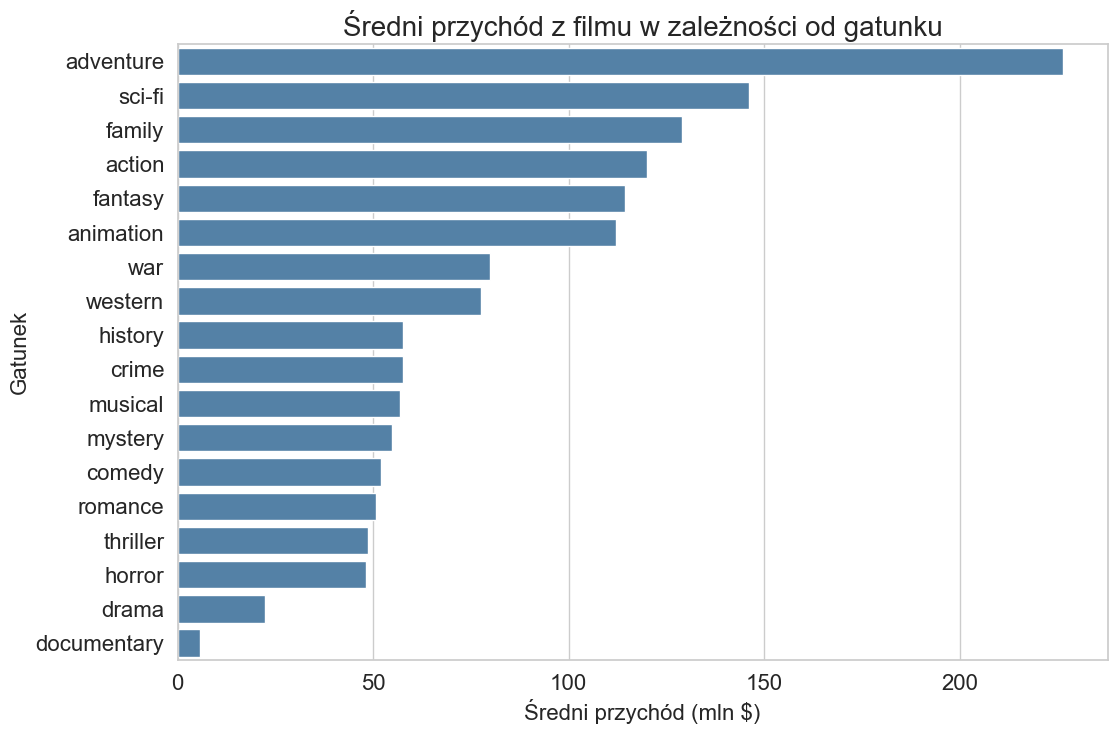

In [39]:
pl_data_rev = data[['revenue_adjusted', 'main_genre']].dropna().copy()
pl_data_rev['revenue_mln'] = pl_data_rev['revenue_adjusted'] / 1e6

plt.figure(figsize=(12, 8))

sns.barplot(
    data=pl_data_rev, 
    x='revenue_mln', 
    y='main_genre', 
    color='steelblue', 
    errorbar=None, 
    order=pl_data_rev.groupby('main_genre')['revenue_mln'].mean().sort_values(ascending=False).index 
)

plt.title('Średni przychód z filmu w zależności od gatunku', fontsize=20)
plt.xlabel('Średni przychód (mln $)', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

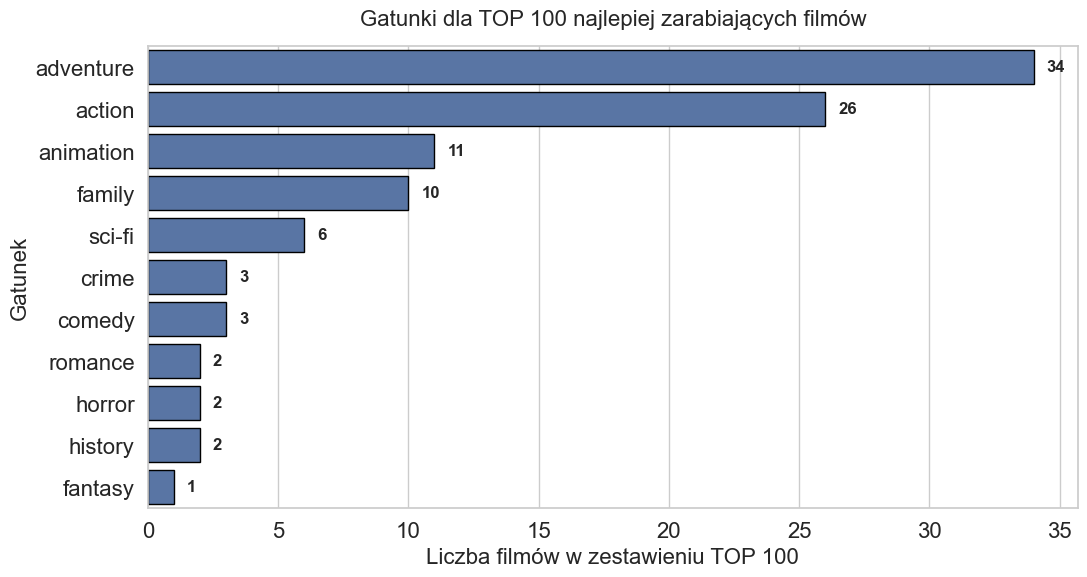

In [40]:
top_100 = data.nlargest(100, 'revenue_adjusted')
ilosc_w_top100 = top_100['main_genre'].value_counts()

plt.figure(figsize=(12, 6))

wykres = sns.barplot(
    x=ilosc_w_top100.values, 
    y=ilosc_w_top100.index, 
    edgecolor='black'
)


plt.title('Gatunki dla TOP 100 najlepiej zarabiających filmów', fontsize=16, pad=15)
plt.xlabel('Liczba filmów w zestawieniu TOP 100', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

for index, value in enumerate(ilosc_w_top100.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=12, fontweight='bold')

plt.show()

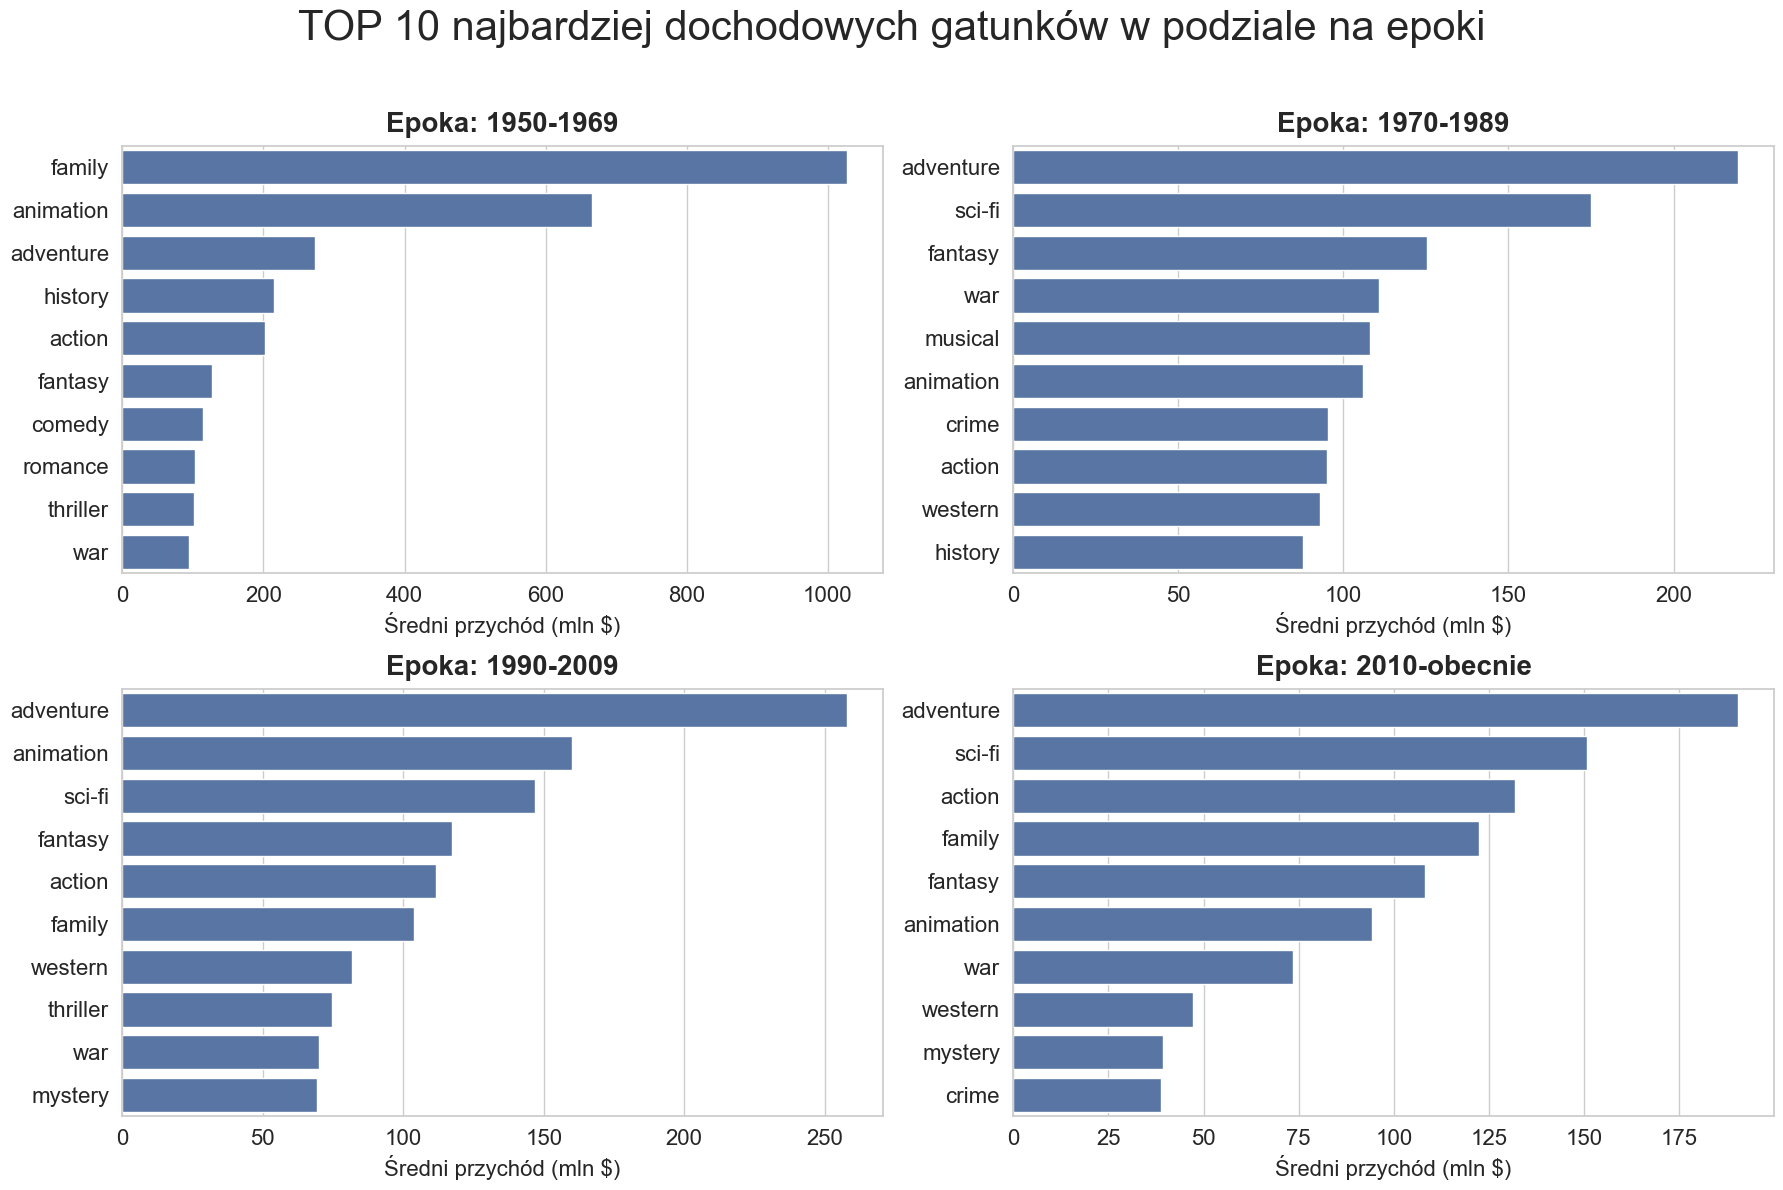

In [41]:
kolejnosc_epok = ['1950-1969', '1970-1989', '1990-2009', '2010-obecnie']


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() 

for i, epoka in enumerate(kolejnosc_epok):

    dane_epoki = data[data['epoka'] == epoka]
    
    ranking = (dane_epoki.groupby('main_genre')['revenue_adjusted']
               .mean() 
               .divide(1e6)
               .sort_values(ascending=False)
               .head(10))
    
    sns.barplot(x=ranking.values, y=ranking.index, ax=axes[i])
    

    axes[i].set_title(f'Epoka: {epoka}', fontsize=20, fontweight='bold', pad=10)
    axes[i].set_xlabel('Średni przychód (mln $)', fontsize=16)
    axes[i].set_ylabel('', fontsize=16)
    axes[i].tick_params(labelsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('TOP 10 najbardziej dochodowych gatunków w podziale na epoki', fontsize=30, y=1.02)

plt.show()

In [42]:
data.head()

,tmdbId,title,budget,revenue,release_date,runtime,original_language,popularity,vote_average,vote_count,...,Semitckie,Indoeuropejskie,Germańskie,Inne/nieznane,Sztuczne,Słowiańskie,Izolat/nieklasyfikowane,Azjatyckie,Uralskie,Romańskie
0,5.0,Four Rooms,4000000.0,4257354,1995-12-09,98,en,3.8441,5.892,2810,...,0,0,1,0,0,0,0,0,0,0
1,6.0,Judgment Night,21000000.0,12136938,1993-10-15,109,en,2.2315,6.469,368,...,0,0,1,0,0,0,0,0,0,0
2,11.0,Star Wars,11000000.0,775398007,1977-05-25,121,en,20.6912,8.200,22061,...,0,0,1,0,0,0,0,0,0,0
3,12.0,Finding Nemo,94000000.0,940335536,2003-05-30,100,en,16.5979,7.817,20364,...,0,0,1,0,0,0,0,0,0,0
4,13.0,Forrest Gump,55000000.0,677387716,1994-06-23,142,en,26.0309,8.500,29387,...,0,0,1,0,0,0,0,0,0,0


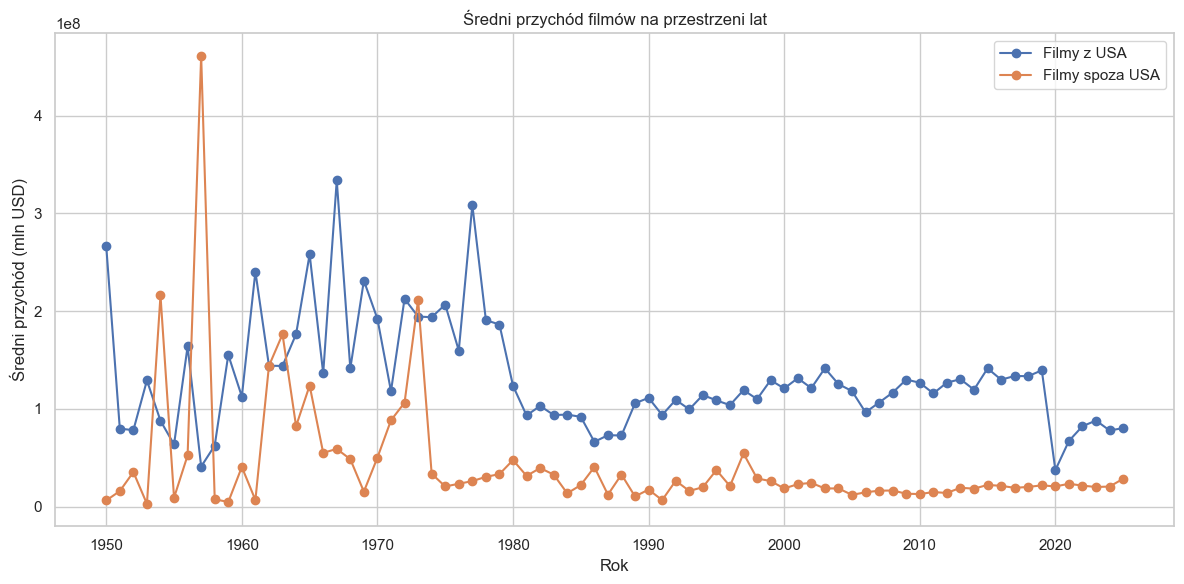

In [76]:
avg_revenue = data.groupby(['year', 'origin_in_US'])['revenue_adjusted'].mean().reset_index()

# Podział na filmy z USA i spoza USA
avg_revenue_us = avg_revenue[avg_revenue['origin_in_US'] == 1]
avg_revenue_non_us = avg_revenue[avg_revenue['origin_in_US'] == 0]

# Wykres liniowy
plt.figure(figsize=(12, 6))
plt.plot(avg_revenue_us['year'], avg_revenue_us['revenue_adjusted'], marker='o', label='Filmy z USA')
plt.plot(avg_revenue_non_us['year'], avg_revenue_non_us['revenue_adjusted'], marker='o', label='Filmy spoza USA')

# Ustawienie co 10 lat na osi X
start_year = avg_revenue['year'].min()
end_year = avg_revenue['year'].max()
plt.xticks(range(start_year, end_year + 1, 10))

plt.title('Średni przychód filmów na przestrzeni lat')
plt.xlabel('Rok')
plt.ylabel('Średni przychód (mln USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
data['origin_countries'] = data['origin_countries'].str.strip('[]').str.split(',')


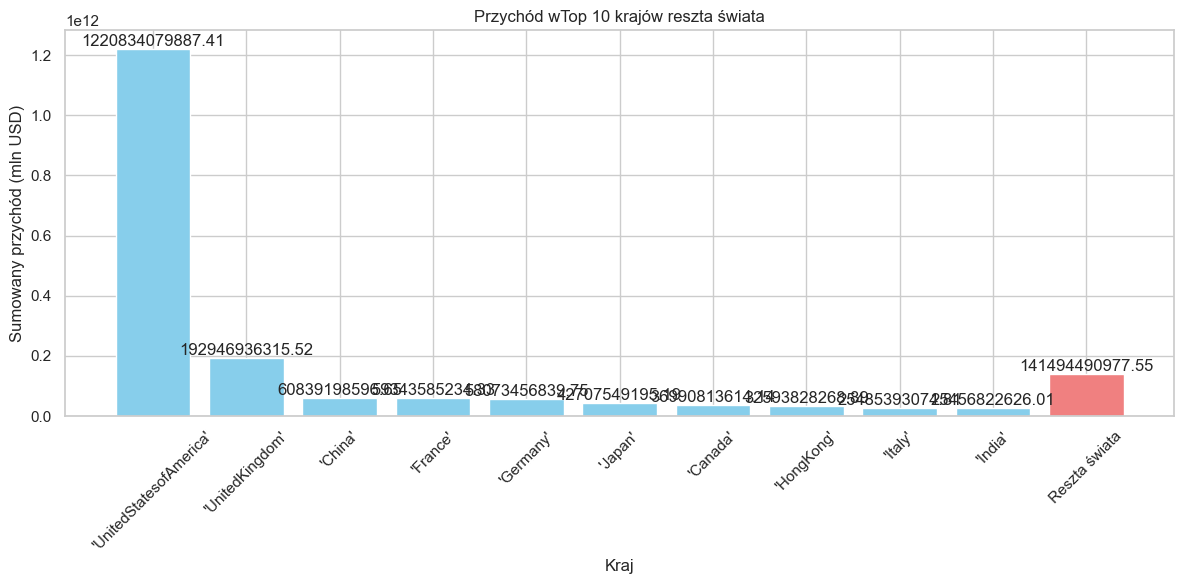

In [79]:

df_exploded = data.explode('origin_countries')
df_exploded['origin_countries'] = df_exploded['origin_countries'].str.strip()
sum_revenue = df_exploded.groupby(['year', 'origin_countries'])['revenue_adjusted'].sum().reset_index()


sum_revenue_by_country = df_exploded.groupby('origin_countries')['revenue_adjusted'].sum().reset_index()

# Sortowanie i wybór top 10
top_10 = sum_revenue_by_country.sort_values('revenue_adjusted', ascending=False).head(10)

# Obliczenie sumy dla pozostałych krajów
rest_sum = sum_revenue_by_country[~sum_revenue_by_country['origin_countries'].isin(top_10['origin_countries'])]['revenue_adjusted'].sum()

# Połączenie top 10 z resztą
final_data = pd.concat([
    top_10,
    pd.DataFrame({'origin_countries': ['Reszta świata'], 'revenue_adjusted': [rest_sum]})
])

# Wykres słupkowy
plt.figure(figsize=(12, 6))
bars = plt.bar(final_data['origin_countries'], final_data['revenue_adjusted'], color=['skyblue']*10 + ['lightcoral'])

# Dodanie wartości na słupkach
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.title('Przychód wTop 10 krajów reszta świata')
plt.xlabel('Kraj')
plt.ylabel('Sumowany przychód (mln USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\klang\AppData\Local\Temp\ipykernel_19588\240169225.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_revenue = df.groupby(['epoka', 'kategoria'])['revenue_adjusted'].sum().reset_index()


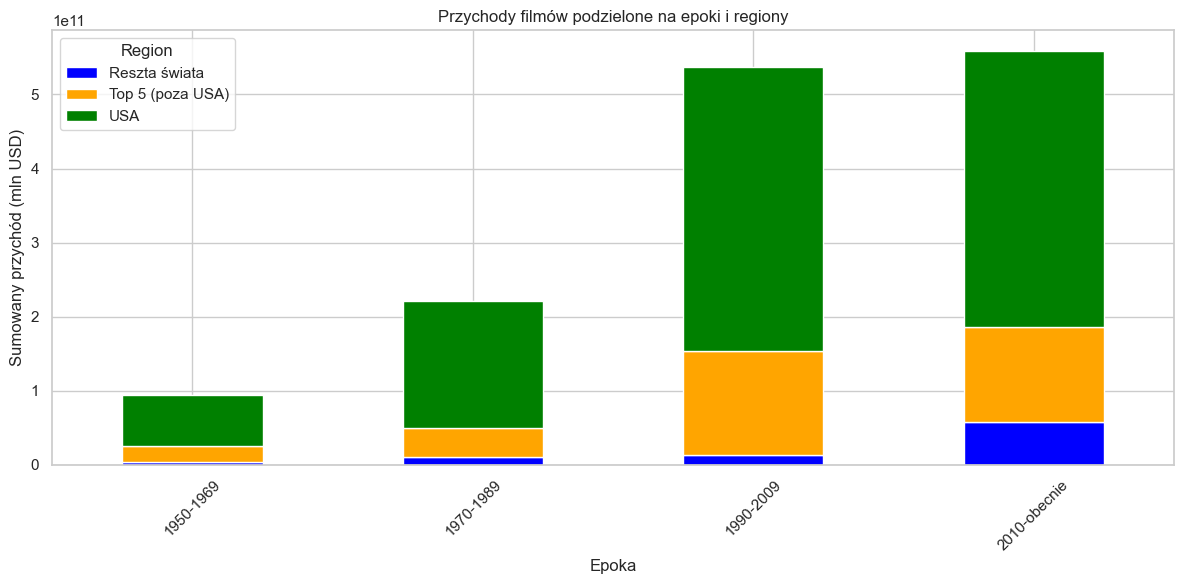

In [80]:
df = data.copy()
df['kategoria'] = 'Reszta świata'
df.loc[df['origin_in_US']==1, 'kategoria'] = 'USA'
df.loc[df['origin_in_top_5']==1, 'kategoria'] = 'Top 5 (poza USA)'

sum_revenue = df.groupby(['epoka', 'kategoria'])['revenue_adjusted'].sum().reset_index()

# Przygotowanie danych do wykresu
pivot_df = sum_revenue.pivot(index='epoka', columns='kategoria', values='revenue_adjusted').fillna(0)

# Wykres słupkowy
pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=['blue', 'orange', 'green'])

plt.title('Przychody filmów podzielone na epoki i regiony')
plt.xlabel('Epoka')
plt.ylabel('Sumowany przychód (mln USD)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

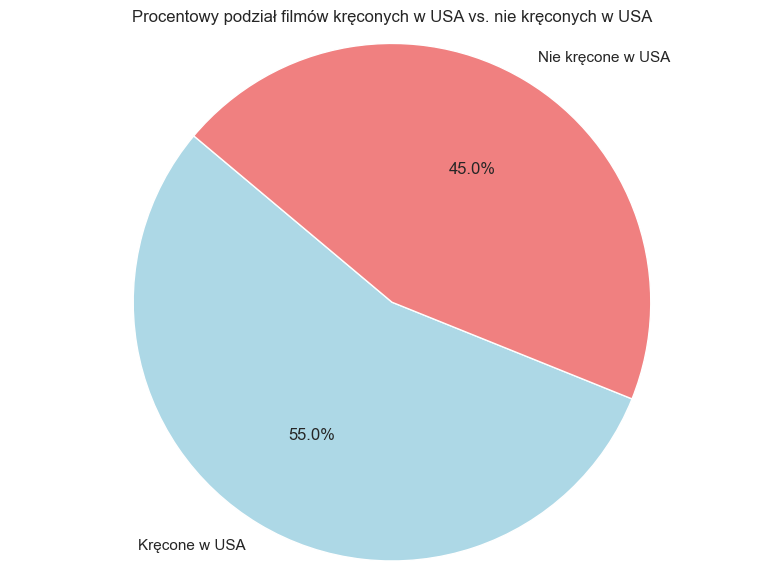

In [81]:
usa_count = df['origin_in_US'].sum()
non_usa_count = len(df) - usa_count

# Dane do wykresu kołowego
labels = ['Kręcone w USA', 'Nie kręcone w USA']
sizes = [usa_count, non_usa_count]
colors = ['lightblue', 'lightcoral']

# Wykres kołowy
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})

plt.title('Procentowy podział filmów kręconych w USA vs. nie kręconych w USA')
plt.axis('equal')  # Zapewnia, że wykres jest kołem
plt.tight_layout()
plt.show()

C:\Users\klang\AppData\Local\Temp\ipykernel_19588\4085445259.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_by_era = df.groupby(['epoka', 'kategoria']).size().reset_index(name='liczba_filmów')


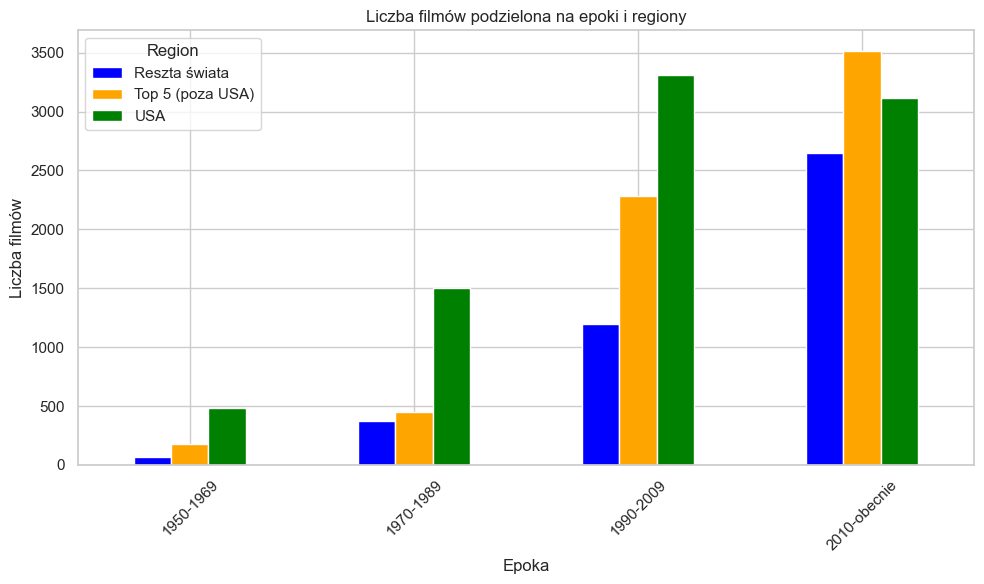

In [49]:
# Zliczenie filmów dla każdej epoki i kategorii
count_by_era = df.groupby(['epoka', 'kategoria']).size().reset_index(name='liczba_filmów')

# Przygotowanie danych do wykresu
pivot_df = count_by_era.pivot(index='epoka', columns='kategoria', values='liczba_filmów').fillna(0)

# Wykres słupkowy
pivot_df.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'], stacked=False)

plt.title('Liczba filmów podzielona na epoki i regiony')
plt.xlabel('Epoka')
plt.ylabel('Liczba filmów')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

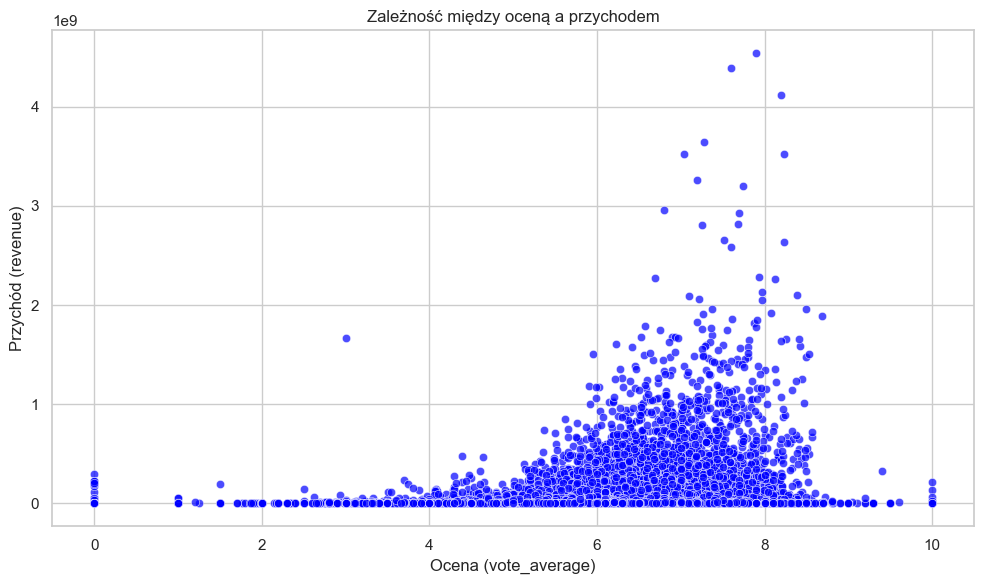

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='vote_average', y='revenue_adjusted', alpha=0.7, color='blue')

plt.title('Zależność między oceną a przychodem')
plt.xlabel('Ocena (vote_average)')
plt.ylabel('Przychód (revenue)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [83]:
language_columns = df.columns[56:-1].tolist()
avg_revenue_by_language = []
for lang in language_columns:
    avg_revenue = df[df[lang] == 1]['revenue_adjusted'].mean()
    avg_revenue_by_language.append(avg_revenue)

# Utworzenie DataFrame z wynikami
avg_revenue_df = pd.DataFrame({
    'Język': language_columns,
    'Średni przychód (mln USD)': avg_revenue_by_language
})

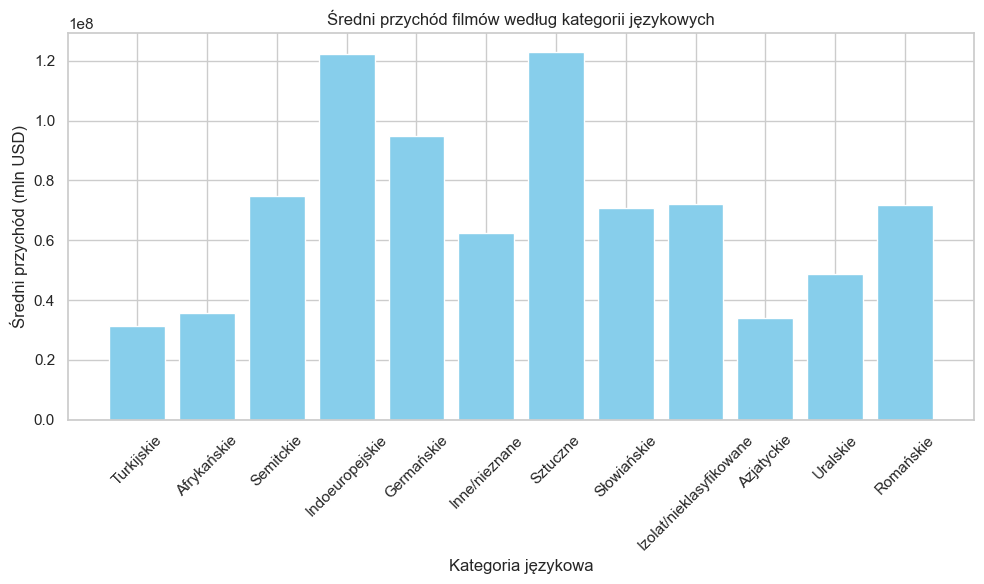

In [84]:
plt.figure(figsize=(10, 6))
plt.bar(avg_revenue_df['Język'], avg_revenue_df['Średni przychód (mln USD)'], color='skyblue')

plt.title('Średni przychód filmów według kategorii językowych')
plt.xlabel('Kategoria językowa')
plt.ylabel('Średni przychód (mln USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

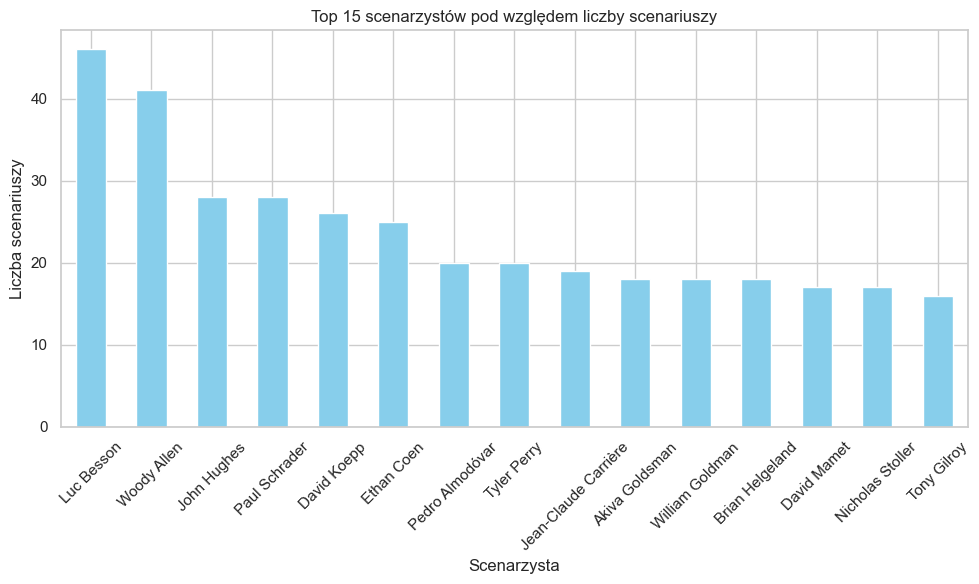

In [85]:
writer_counts = df['writer_name'].value_counts()

# Wybór top N scenarzystów (np. N=3)
N = 15
top_writers = writer_counts.head(N)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
top_writers.plot(kind='bar', color='skyblue')

plt.title(f'Top {N} scenarzystów pod względem liczby scenariuszy')
plt.xlabel('Scenarzysta')
plt.ylabel('Liczba scenariuszy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

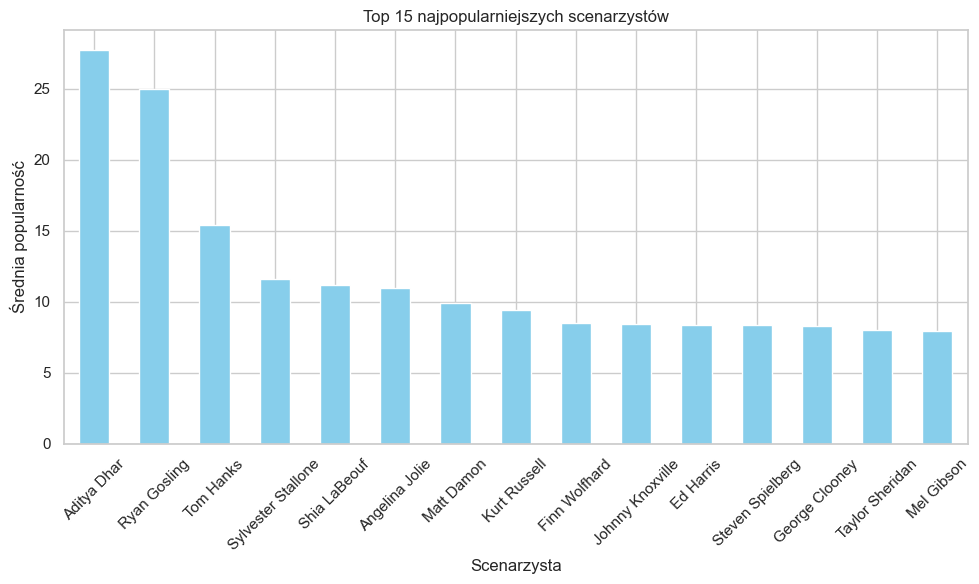

In [86]:
avg_popularity = df.groupby('writer_name')['writer_popularity'].mean().sort_values(ascending=False)

# Wybór top N najpopularniejszych scenarzystów (np. N=3)
N = 15
top_writers = avg_popularity.head(N)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
top_writers.plot(kind='bar', color='skyblue')

plt.title(f'Top {N} najpopularniejszych scenarzystów')
plt.xlabel('Scenarzysta')
plt.ylabel('Średnia popularność')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

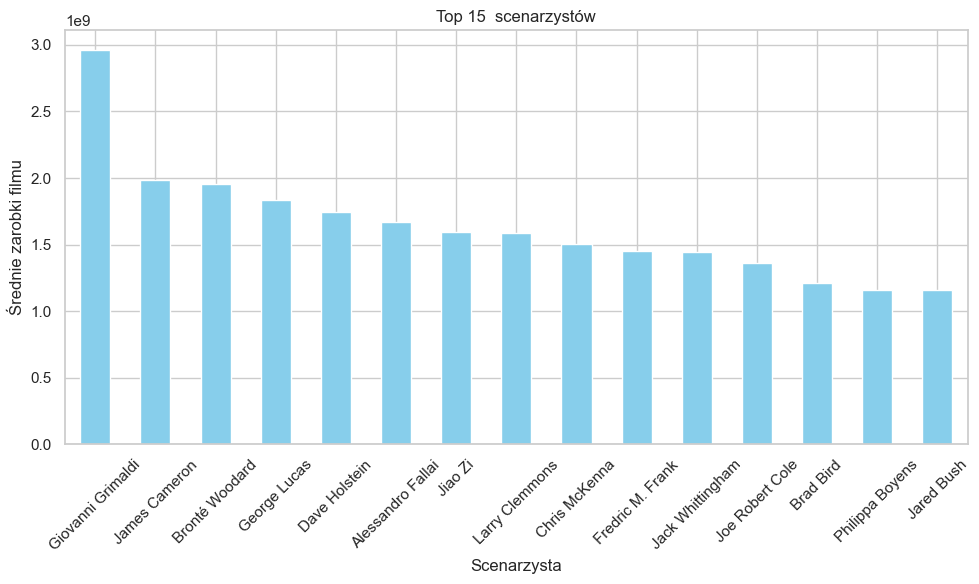

In [87]:
avg_popularity = df.groupby('writer_name')['revenue_adjusted'].mean().sort_values(ascending=False)

# Wybór top N najpopularniejszych scenarzystów (np. N=3)
N = 15
top_writers = avg_popularity.head(N)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
top_writers.plot(kind='bar', color='skyblue')

plt.title(f'Top {N}  scenarzystów')
plt.xlabel('Scenarzysta')
plt.ylabel('Średnie zarobki filmu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

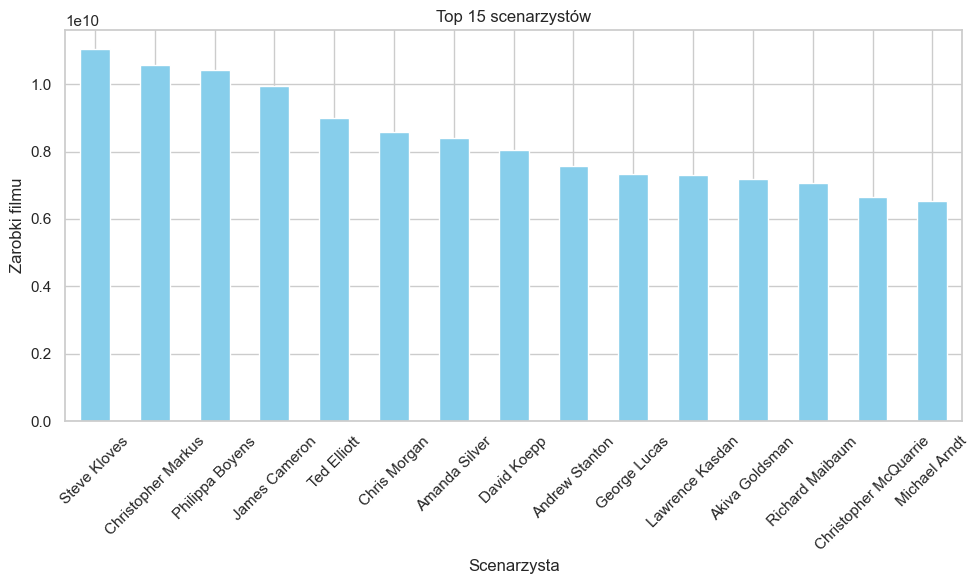

In [88]:
avg_popularity = df.groupby('writer_name')['revenue_adjusted'].sum().sort_values(ascending=False)

# Wybór top N najpopularniejszych scenarzystów (np. N=3)
N = 15
top_writers = avg_popularity.head(N)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
top_writers.plot(kind='bar', color='skyblue')

plt.title(f'Top {N} scenarzystów')
plt.xlabel('Scenarzysta')
plt.ylabel('Zarobki filmu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

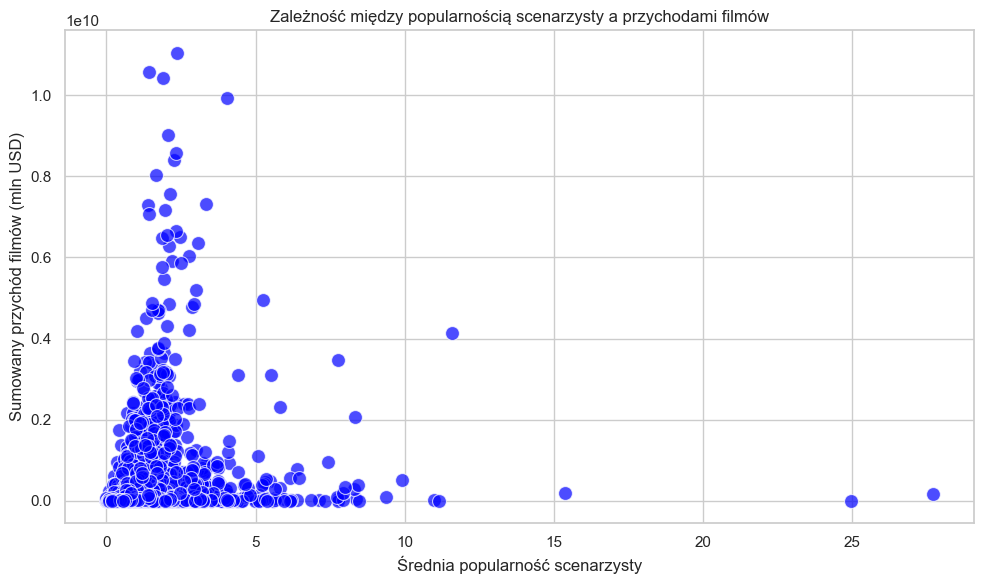

In [89]:
# Obliczenie średniej popularności i sumowanego przychodu dla każdego scenarzysty
writer_stats = df.groupby('writer_name').agg({
    'writer_popularity': 'mean',
    'revenue_adjusted': 'sum'
}).reset_index()

# Wykres rozrzutu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=writer_stats, x='writer_popularity', y='revenue_adjusted', s=100, color='blue', alpha=0.7)

plt.title('Zależność między popularnością scenarzysty a przychodami filmów')
plt.xlabel('Średnia popularność scenarzysty')
plt.ylabel('Sumowany przychód filmów (mln USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

Top 15 najpopularniejszych aktorów:
actor_name
Chuck Norris          46.740804
Sydney Sweeney        35.046422
Jason Statham         30.778493
Tom Cruise            27.507958
Matt Clark            26.202700
Jackie Chan           25.778635
Julia Piaton          24.284475
Tom Holland           22.898405
Timothée Chalamet     21.787000
Michael B. Jordan     21.611192
Ryan Gosling          20.527192
Jessie Buckley        20.421186
Scarlett Johansson    20.185298
Tom Hanks             18.584374
Sandra Ng Kwan-Yu     18.250580
Name: popularity, dtype: float64


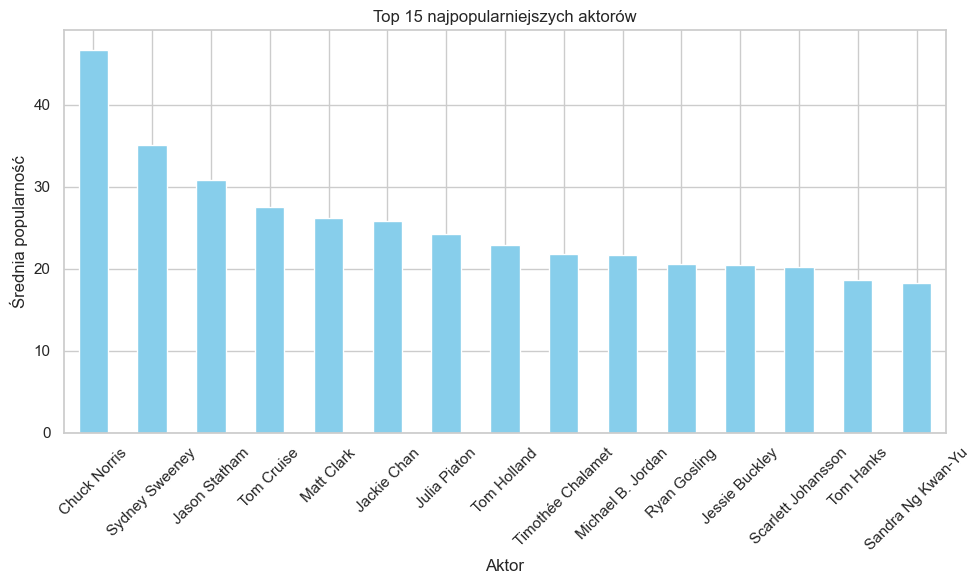

In [90]:
actors = []
popularities = []
for i in range(1, 6):
    actors.extend(df[f'actor{i}_name'].dropna())
    popularities.extend(df[f'actor{i}_popularity'].dropna())

# Utworzenie DataFrame z aktorami i ich popularnością
actors_df = pd.DataFrame({'actor_name': actors, 'popularity': popularities})

# Obliczenie średniej popularności dla każdego aktora
avg_popularity = actors_df.groupby('actor_name')['popularity'].mean().sort_values(ascending=False)

# Wybór top N aktorów (np. N=5)
N = 15
top_actors = avg_popularity.head(N)

# Wyświetlenie wyników
print(f"Top {N} najpopularniejszych aktorów:")
print(top_actors)

# Wykres słupkowy (opcjonalnie)
plt.figure(figsize=(10, 6))
top_actors.plot(kind='bar', color='skyblue')

plt.title(f'Top {N} najpopularniejszych aktorów')
plt.xlabel('Aktor')
plt.ylabel('Średnia popularność')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

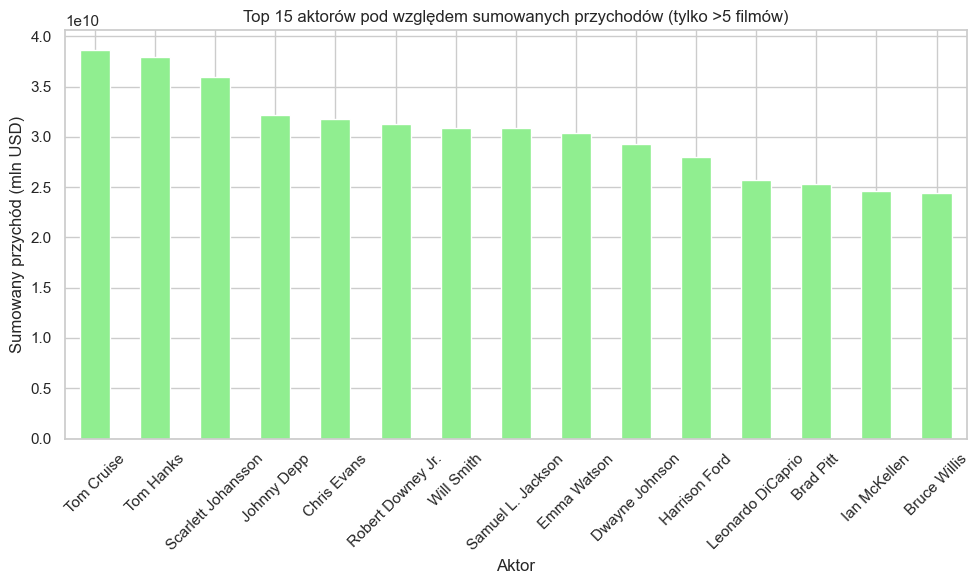

In [91]:
# actors = []
# revenues = []
# df_wo_anim = df[df['main_genre']!='animation']
actors = []
revenues = []
for i in range(1, 6):
    actors.extend(df[f'actor{i}_name'])
    revenues.extend(df['revenue_adjusted'])

# Utworzenie DataFrame z aktorami i przychodami
actors_df = pd.DataFrame({'actor_name': actors, 'revenue_adjusted': revenues})

# Zliczenie liczby filmów dla każdego aktora
actor_counts = actors_df['actor_name'].value_counts()

# Odfiltrowanie aktorów, którzy wystąpili w więcej niż 5 filmach
frequent_actors = actor_counts[actor_counts >= 5].index
filtered_actors_df = actors_df[actors_df['actor_name'].isin(frequent_actors)]

# Zsumowanie przychodów dla każdego aktora
sum_revenue = filtered_actors_df.groupby('actor_name')['revenue_adjusted'].sum().sort_values(ascending=False)

# Wybór top N aktorów (np. N=5)
N = 15
top_actors_by_revenue = sum_revenue.head(N)

# Wykres słupkowy
plt.figure(figsize=(10, 6))
top_actors_by_revenue.plot(kind='bar', color='lightgreen')

plt.title(f'Top {N} aktorów pod względem sumowanych przychodów (tylko >5 filmów)')
plt.xlabel('Aktor')
plt.ylabel('Sumowany przychód (mln USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\klang\AppData\Local\Temp\ipykernel_19588\2425358681.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_actors_by_era = sum_revenue_by_era.groupby('era').apply(


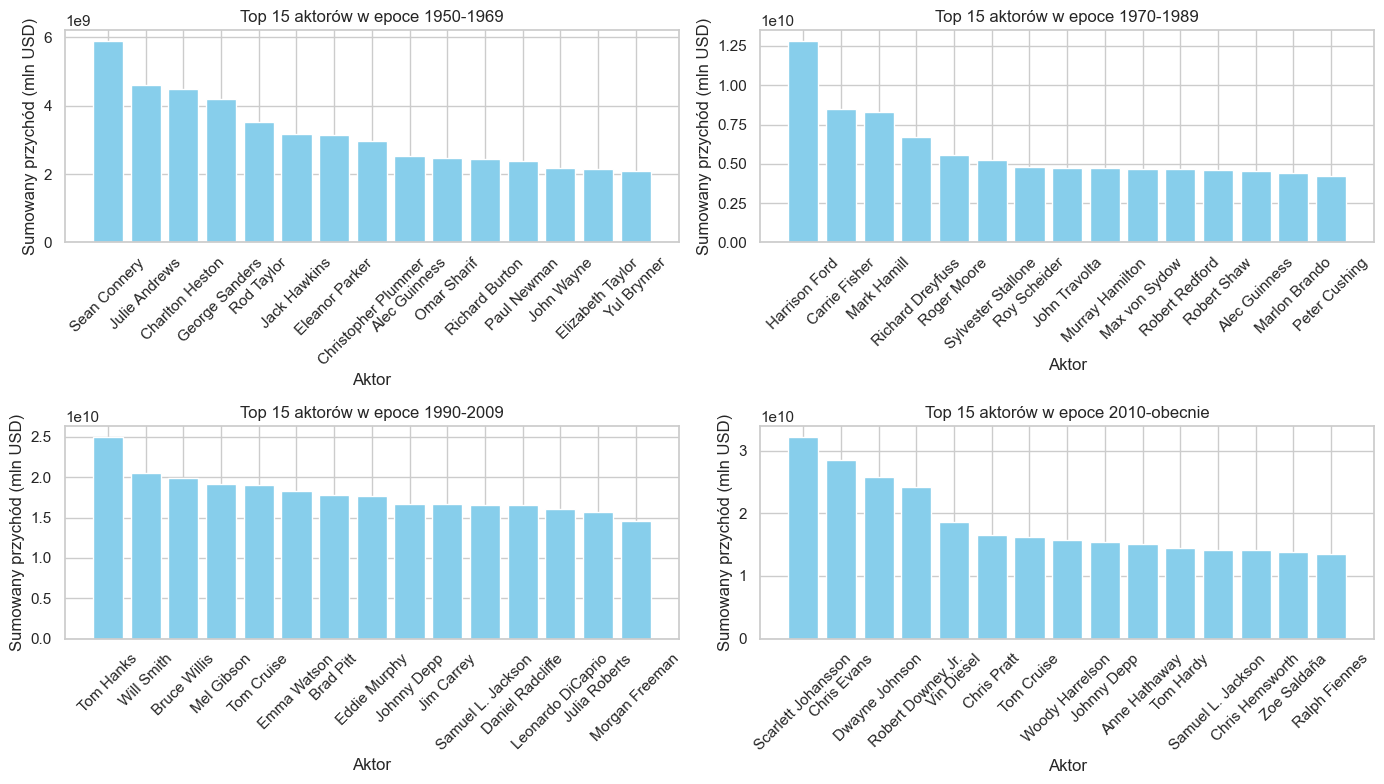

In [92]:
actors = []
revenues = []
eras = []
for i in range(1, 6):
    actors.extend(df[f'actor{i}_name'])
    revenues.extend(df['revenue_adjusted'])
    eras.extend(df['epoka'])

# Utworzenie DataFrame z aktorami, przychodami i epoką
actors_df = pd.DataFrame({'actor_name': actors, 'revenue_adjusted': revenues, 'era': eras})


# Zliczenie liczby filmów dla każdego aktora
actor_counts = actors_df['actor_name'].value_counts()

# Odfiltrowanie aktorów, którzy wystąpili w więcej niż 5 filmach
frequent_actors = actor_counts[actor_counts > 5].index
filtered_actors_df = actors_df[actors_df['actor_name'].isin(frequent_actors)]

# Zsumowanie przychodów dla każdego aktora w każdej epoce
sum_revenue_by_era = filtered_actors_df.groupby(['era', 'actor_name'])['revenue_adjusted'].sum().reset_index()

# Wybór top N aktorów dla każdej epoki (np. N=3)
N = 15
top_actors_by_era = sum_revenue_by_era.groupby('era').apply(
    lambda x: x.nlargest(N, 'revenue_adjusted')
).reset_index(drop=True)

# Wykres słupkowy dla każdej epoki
plt.figure(figsize=(14, 8))
for i, era in enumerate(top_actors_by_era['era'].unique()):
    era_data = top_actors_by_era[top_actors_by_era['era'] == era]
    plt.subplot(2, 2, i+1)
    plt.bar(era_data['actor_name'], era_data['revenue_adjusted'], color='skyblue')
    plt.title(f'Top {N} aktorów w epoce {era}')
    plt.xlabel('Aktor')
    plt.ylabel('Sumowany przychód (mln USD)')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

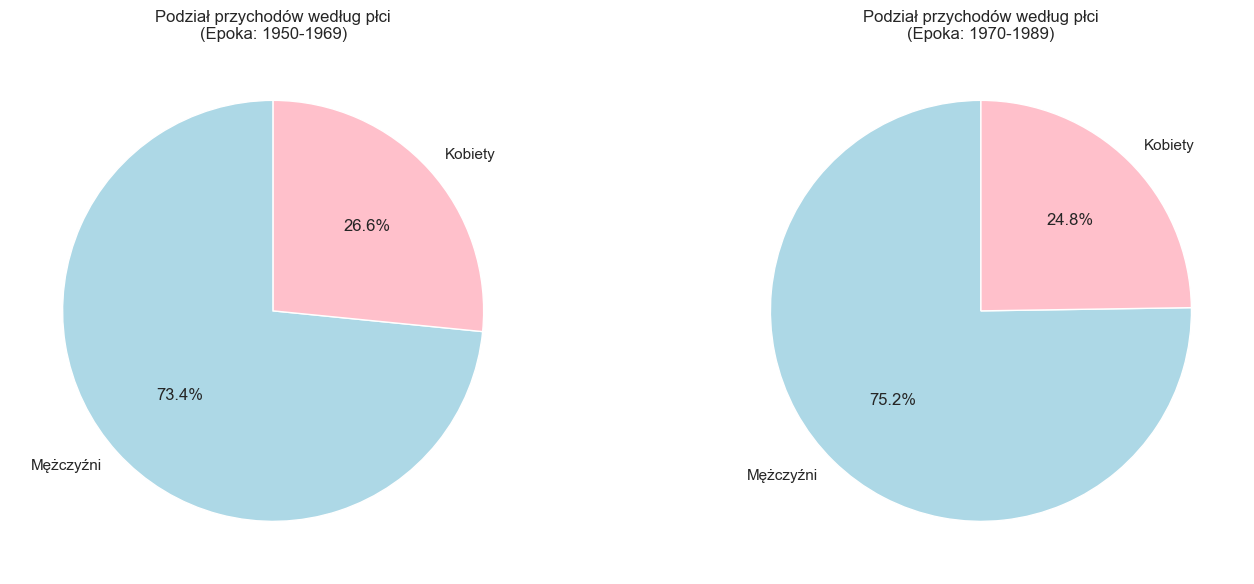

In [93]:
# Przekształcenie danych do postaci "długiej"
actors = []
genders = []
revenues = []
eras = []
for i in range(1, 6):
    actors.extend(df[f'actor{i}_name'])
    genders.extend(df[f'actor{i}_gender'])
    revenues.extend(df['revenue_adjusted'])
    eras.extend(df['epoka'])

# Utworzenie DataFrame z aktorami, płcią, przychodami i epoką
actors_df = pd.DataFrame({
    'actor_name': actors,
    'gender': genders,
    'revenue_adjusted': revenues,
    'era': eras
})

# Zliczenie liczby filmów dla każdego aktora
actor_counts = actors_df['actor_name'].value_counts()

# Odfiltrowanie aktorów, którzy wystąpili w więcej niż 5 filmach
frequent_actors = actor_counts[actor_counts > 5].index
filtered_actors_df = actors_df[actors_df['actor_name'].isin(frequent_actors)]

# Zsumowanie przychodów dla każdej płci w każdej epoce
sum_revenue_by_era_gender = filtered_actors_df.groupby(['era', 'gender'])['revenue_adjusted'].sum().reset_index()

# Wykresy kołowe dla każdej epoki
eras = sum_revenue_by_era_gender['era'].unique()
fig, axes = plt.subplots(1,2, figsize=(15, 6))

for i, era in enumerate(eras):
    if i==2 or i==3:continue
    era_data = sum_revenue_by_era_gender[sum_revenue_by_era_gender['era'] == era]
    labels = ['Mężczyźni', 'Kobiety']
    sizes = [era_data[era_data['gender'] == 2]['revenue_adjusted'].sum(),
             era_data[era_data['gender'] == 1]['revenue_adjusted'].sum()]
    colors = ['lightblue', 'pink']

    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Podział przychodów według płci\n(Epoka: {era})')

plt.tight_layout()
plt.show()

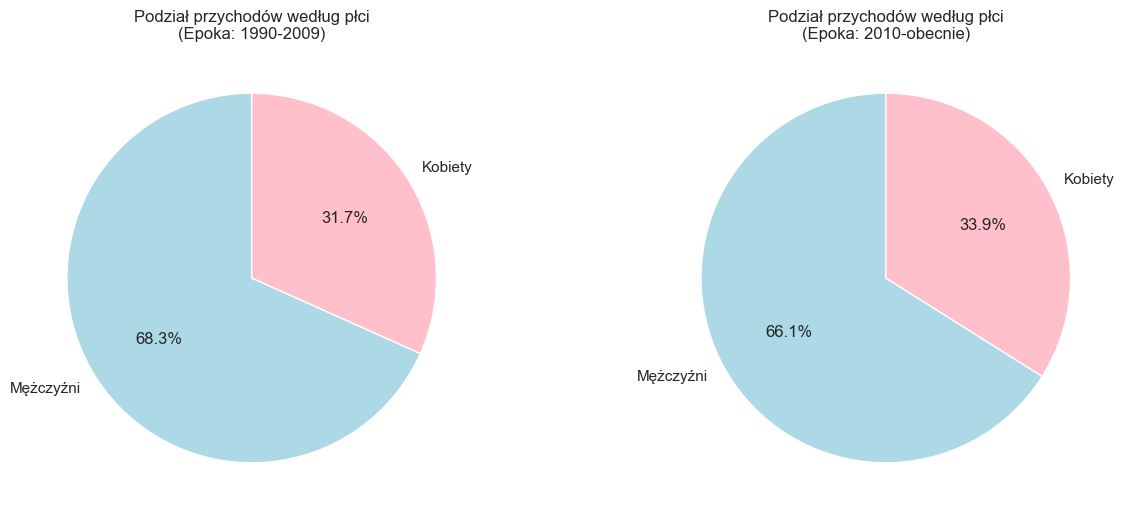

In [94]:
fig, axes = plt.subplots(1,2, figsize=(15, 6))
for i, era in enumerate(eras):
    if i==0 or i==1:continue
    era_data = sum_revenue_by_era_gender[sum_revenue_by_era_gender['era'] == era]
    labels = ['Mężczyźni', 'Kobiety']
    sizes = [era_data[era_data['gender'] == 2]['revenue_adjusted'].sum(),
             era_data[era_data['gender'] == 1]['revenue_adjusted'].sum()]
    colors = ['lightblue', 'pink']

    axes[i-2].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i-2].set_title(f'Podział przychodów według płci\n(Epoka: {era})')

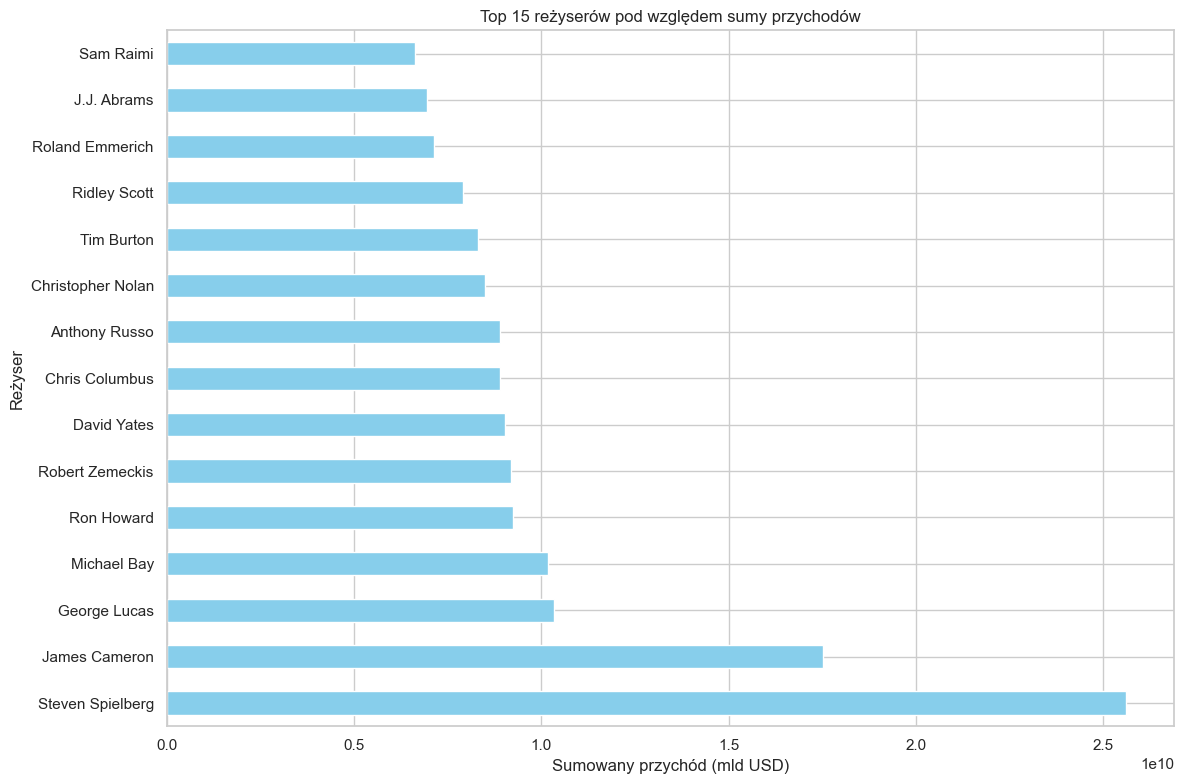

In [95]:
director_revenue = df.groupby('director_name')['revenue_adjusted'].sum().sort_values(ascending=False)

# Wybór top 15 reżyserów
top_15_directors = director_revenue.head(15)

# Wykres poziomy (lepszy dla długich nazw)
plt.figure(figsize=(12, 8))
top_15_directors.plot(kind='barh', color='skyblue')
plt.title('Top 15 reżyserów pod względem sumy przychodów')
plt.xlabel('Sumowany przychód (mld USD)')
plt.ylabel('Reżyser')
plt.tight_layout()
plt.show()

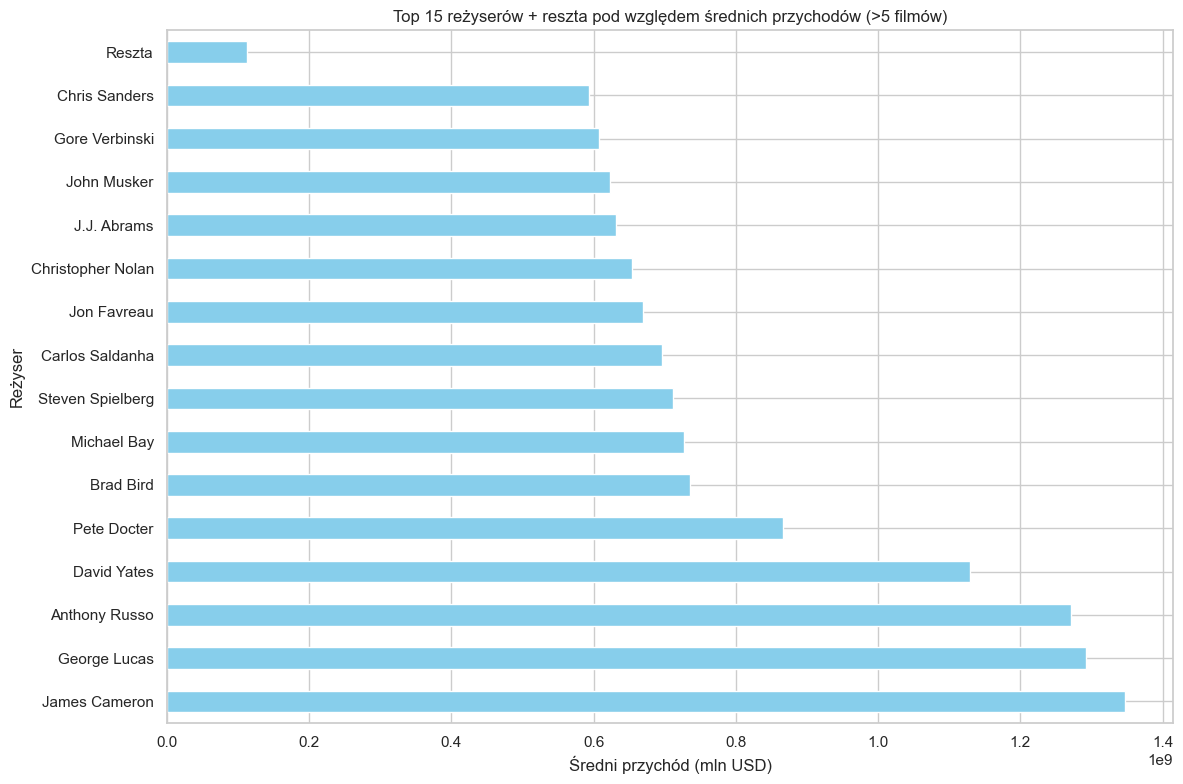

In [96]:
director_counts = df['director_name'].value_counts()

frequent_directors = director_counts[director_counts > 5].index
filtered_df = df[df['director_name'].isin(frequent_directors)]

# Zsumowanie przychodów dla tych reżyserów
director_revenue = filtered_df.groupby('director_name')['revenue_adjusted'].mean().sort_values(ascending=False)
# Wybór top 15 reżyserów
top_15 = director_revenue.head(15)
others = director_revenue[15:].mean()

# Połączenie top 15 z "Resztą" jako nowa Series
all_directors = pd.concat([top_15, pd.Series({'Reszta': others})])

# Wykres poziomy
plt.figure(figsize=(12, 8))
all_directors.plot(kind='barh', color='skyblue')
plt.title('Top 15 reżyserów + reszta pod względem średnich przychodów (>5 filmów)')
plt.xlabel('Średni przychód (mln USD)')
plt.ylabel('Reżyser')
plt.tight_layout()
plt.show()

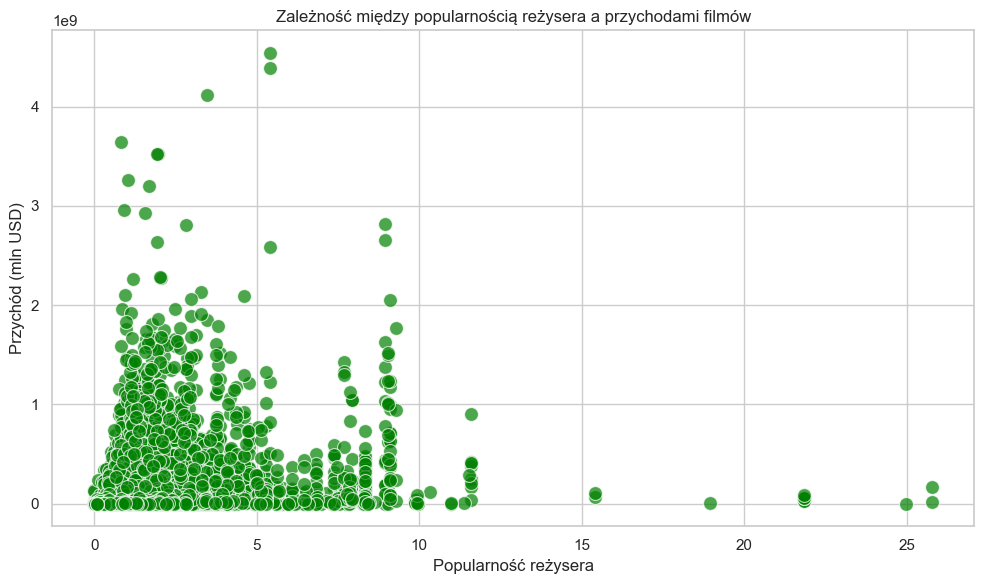

In [98]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='director_popularity', y='revenue_adjusted', s=100, color='green', alpha=0.7)
plt.title('Zależność między popularnością reżysera a przychodami filmów')
plt.xlabel('Popularność reżysera')
plt.ylabel('Przychód (mln USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

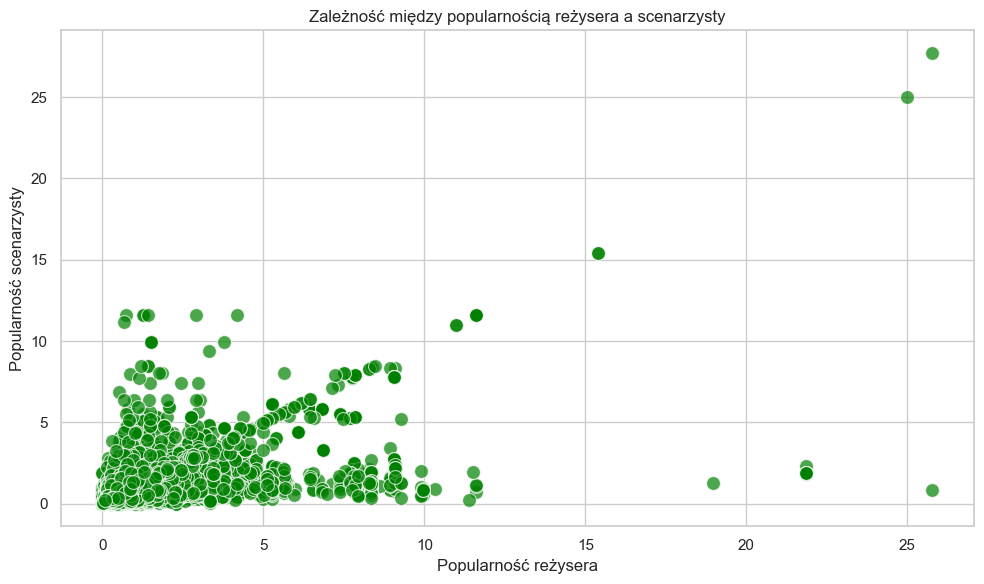

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='director_popularity', y='writer_popularity', s=100, color='green', alpha=0.7)
plt.title('Zależność między popularnością reżysera a scenarzysty')
plt.xlabel('Popularność reżysera')
plt.ylabel('Popularność scenarzysty')
plt.grid(True)
plt.tight_layout()
plt.show()

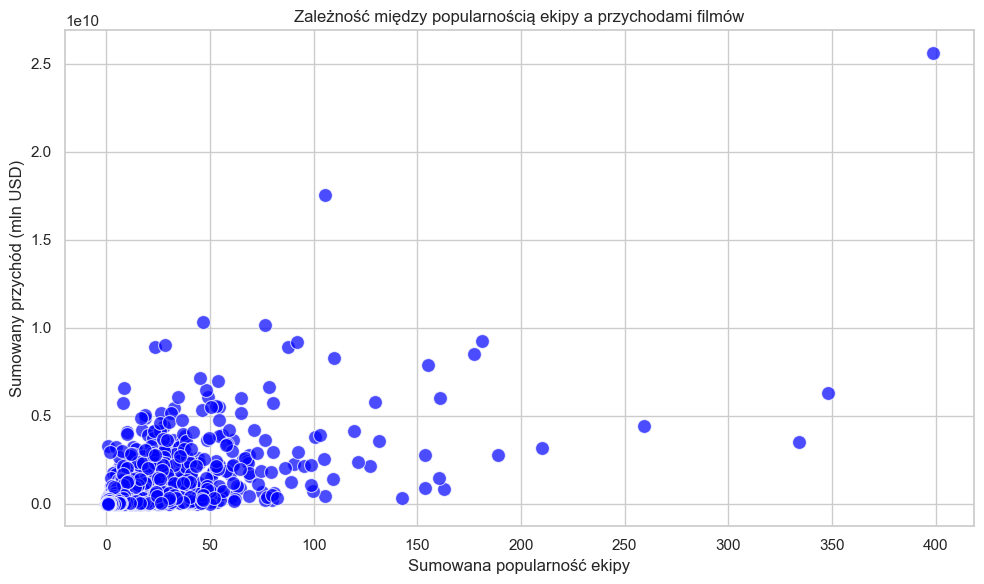

In [99]:
# Agregacja danych dla każdego reżysera
director_stats = df.groupby('director_name').agg({
    'total_crew_popularity': 'sum',
    'revenue_adjusted': 'sum'
}).reset_index()

# Wykres rozrzutu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=director_stats, x='total_crew_popularity', y='revenue_adjusted', s=100, color='blue', alpha=0.7)
plt.title('Zależność między popularnością ekipy a przychodami filmów')
plt.xlabel('Sumowana popularność ekipy')
plt.ylabel('Sumowany przychód (mln USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

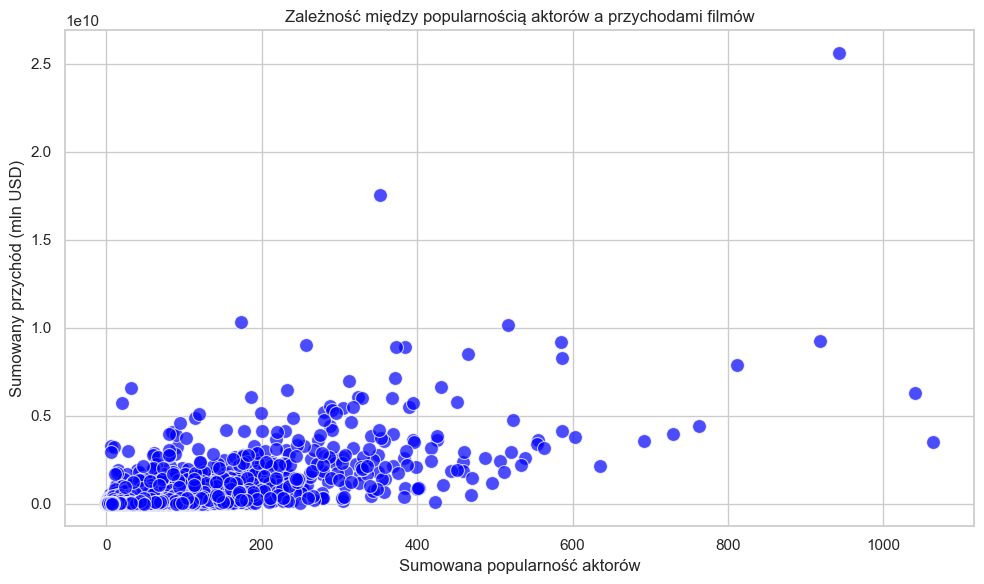

In [100]:
# Agregacja danych dla każdego reżysera
director_stats = df.groupby('director_name').agg({
    'total_actors_popularity': 'sum',
    'revenue_adjusted': 'sum'
}).reset_index()

# Wykres rozrzutu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=director_stats, x='total_actors_popularity', y='revenue_adjusted', s=100, color='blue', alpha=0.7)
plt.title('Zależność między popularnością aktorów a przychodami filmów')
plt.xlabel('Sumowana popularność aktorów')
plt.ylabel('Sumowany przychód (mln USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

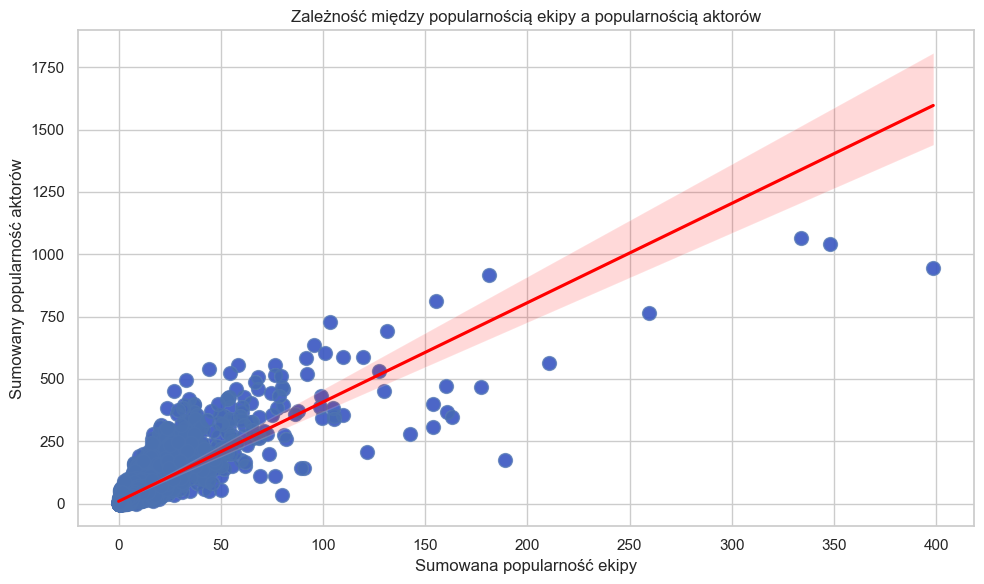

In [103]:
# Agregacja danych dla każdego reżysera
director_stats = df.groupby('director_name').agg({
    'total_crew_popularity': 'sum',
    'total_actors_popularity': 'sum'
}).reset_index()

# Wykres rozrzutu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=director_stats, x='total_crew_popularity', y='total_actors_popularity', s=100, color='blue', alpha=0.7)
sns.regplot(data=director_stats, x='total_crew_popularity', y='total_actors_popularity',
            scatter_kws={'s': 100, 'alpha': 0.7}, line_kws={'color': 'red'})
plt.title('Zależność między popularnością ekipy a popularnością aktorów')
plt.xlabel('Sumowana popularność ekipy')
plt.ylabel('Sumowany popularność aktorów')
plt.grid(True)
plt.tight_layout()
plt.show()